# Single-Cell Spatial Proteomics Analysis: Human Liver Zonation (scDVP Study)

This notebook demonstrates a complete proteomics analysis workflow using **alphapepttools**, reproducing and extending the analysis from the scDVP (single-cell Deep Visual Proteomics) study of human liver zonation: https://www.biorxiv.org/content/10.1101/2025.04.13.648568v1.

## 1. Study Background

In liver lobules, hepatocytes perform distinct metabolic functions depending on their spatial position along the axis from the portal vein to the central vein, a phenomenon known as liver zonation. In the [study by Weiss and colleagues](https://www.biorxiv.org/content/10.1101/2025.04.13.648568v1), single hepatocytes were isolated along this porto-central axis using laser microdissection, followed by mass-spectrometry–based single-cell proteomics. By preserving information about each cell’s spatial origin within the intact tissue, the authors were able to reconstruct spatial trajectories for thousands of proteins and quantify how protein expression patterns change across zonation in both healthy and pathological states.

Single-cell proteomics is a low-input application of mass spectrometry, which introduces several analytical challenges, including a high proportion of missing values, missingness that is not random, and increased susceptibility to technical noise. In this tutorial, we will use this dataset to demonstrate practical strategies for exploring, processing, and interpreting scDVP proteomics data.

## 2. Learning Objectives

1. **Data Loading & Preprocessing**: Import proteomics data into the AnnData format
2. **Quality Control**: Assess sample and protein quality, identify batch effects if any exist
3. **Filtering**: Apply informed thresholds based on QC metrics
4. **Dimensionality Reduction**: Use PCA to explore variance structure
5. **Biological Interpretation**: Recreate zonation heatmaps and infer transcription factor activity

## 3. Key Proteomics Considerations

| Challenge | Why It Matters | Our Approach |
|-----------|---------------|--------------|
| **Missing values** | Proteomics data is ~20-50% missing (MNAR) | Flag, don't impute blindly |
| **Dynamic range** | Proteins span 6+ orders of magnitude | Log-transform intensities |
| **Batch effects** | Donor/plate effects can dominate | QC visualization, consider correction |
| **Low protein counts** | Single-cell = fewer IDs than bulk | Filter carefully |

---

## 4. References

  - **scDVP Study**: Weiss, C.A.M., et al. (2025). Single cell spatial proteomics maps human liver zonation patterns and their vulnerability to fibrosis. bioRxiv. https://doi.org/10.1101/2025.04.13.648568

  - **DirectLFQ**: Ammar, C., et al. (2023). Accurate label-free quantification by directLFQ to compare unlimited numbers of proteomes. Molecular & Cellular Proteomics, 22(7). https://doi.org/10.1016/j.mcpro.2023.100581

  - **DIANN**: Demichev, Vadim, et al. "DIA-NN: neural networks and interference correction enable deep proteome coverage in high throughput." Nature methods 17.1 (2020): 41-44.

  - **Scanpy**: Wolf, F.A., Angerer, P., & Theis, F.J. (2018). SCANPY: large-scale single-cell gene expression data analysis. Genome Biology, 19(1), 15. https://doi.org/10.1186/s13059-017-1382-0

  - **Single-cell Best Practices (RNA-seq)**: Luecken, M.D., & Theis, F.J. (2019). Current best practices in single-cell RNA-seq analysis: a tutorial. Molecular Systems Biology, 15(6), e8746. https://doi.org/10.15252/msb.20188746

  - **Single-cell Best Practices (Multi-modal)**: Heumos, L., et al. (2023). Best practices for single-cell analysis across modalities. Nature Reviews Genetics, 24(8), 550-572. https://doi.org/10.1038/s41576-023-00586-w

  - **Decoupler**: Badia-i-Mompel, P., et al. (2022). decoupleR: ensemble of computational methods to infer biological activities from omics data. Bioinformatics Advances, 2(1), vbac016. https://doi.org/10.1093/bioadv/vbac016



In [ ]:
import alphapepttools as at
import matplotlib.pyplot as plt
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import warnings
import tempfile
from alphapepttools.pl.colors import BaseColormaps, get_color_mapping
from alphapepttools.pl.figure import create_figure, label_axes
from alphapepttools.pl.colors import BaseColors
from alphapepttools.tl.plot_data_handling import prepare_pca_1d_loadings_data_to_plot

---

## 5. Data Loading
We load the dataset used for the study which contains 769 heptocytes taken from 18 donors, with a total of 5175 identified protein groups. 
The data were analyzed with DIA-NN and resulted report file was normalized using directLFQ.

In [ ]:
output_dir = "./datasets/data_for_study_04_scDVP_Hep_workflow"

pg_table_path = at.data.get_data("Weiss2026_pg_directLFQ", output_dir=output_dir if output_dir else tempfile.mkdtemp())
obs_metadata_path = at.data.get_data("Weiss2026_metadata", output_dir=output_dir if output_dir else tempfile.mkdtemp())
var_metadata_path = at.data.get_data(
    "Uniprot_to_GeneSymbol_file", output_dir=output_dir if output_dir else tempfile.mkdtemp()
)

adata = at.io.read_pg_table(pg_table_path, search_engine="directlfq")
obs_metadata = pd.read_csv(obs_metadata_path, sep=",", index_col=0)
var_metadata = pd.read_csv(var_metadata_path, sep=",", index_col=0)


# print adata and metadata to verify successful loading
display(adata.to_df().head())
display(obs_metadata.head())
display(var_metadata.head())

./datasets/data_for_study_04_scDVP_Hep_workflow/scDVP.report.tsv.protein_intensities.tsv already exists (37.4078893661499 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/metadata_scDVP.csv already exists (0.08909797668457031 MB)
./datasets/data_for_study_04_scDVP_Hep_workflow/Uniprot_to_GeneSymbol.csv already exists (0.15979480743408203 MB)


uniprot_ids,A0A024R1R8;Q9Y2S6,A0A075B6H7;A0A0C4DH55;P01624,A0A075B6I0,A0A075B6K4,A0A075B6K5,A0A075B6P5;P01615,A0A075B6R9;A0A0C4DH68,A0A087WSY6,A0A0A0MRZ8;P04433,A0A0A0MS15,...,Q9Y6N8,Q9Y6Q5,Q9Y6R1,Q9Y6R7,Q9Y6U3,Q9Y6V7,Q9Y6W3,Q9Y6X4,Q9Y6Y8,Q9Y6Z7
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,9662.634298,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,0.000000,13032.087818,0.0,0.0,0.000000,0.000000,0.0,0.0,13694.136179,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,0.000000,16351.507957,0.0,0.0,0.000000,6400.357454,0.0,0.0,10409.959084,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,4860.785945,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,21068.309869,21729.115322,0.0,0.0,2352.444061,5735.512100,0.0,0.0,10518.617833,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12174.755055,7423.415566,0.0
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


,id,score,donor_id,plate_id,condition
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,92.0,0.172537,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,95.0,0.289923,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,99.0,0.389010,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,104.0,0.534056,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,109.0,0.632710,CHTL36,plate_2,desmoplasia


,Protein.Group,Protein.Names,Genes
protein,,,
A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B
A0A075B6H7;A0A0C4DH55;P01624,A0A075B6H7;A0A0C4DH55;P01624,KV315_HUMAN;KV37_HUMAN;KVD07_HUMAN,IGKV3-15;IGKV3-7;IGKV3D-7
A0A075B6I0,A0A075B6I0,LV861_HUMAN,IGLV8-61
A0A075B6K4,A0A075B6K4,LV310_HUMAN,IGLV3-10
A0A075B6K5,A0A075B6K5,LV39_HUMAN,IGLV3-9


## 5.1 Joining metadata to quantitative data

Next, we join the metadata for the `obs` and `var` to have the complete dataset in the anndata.

In [ ]:
# add the metadata to the AnnData object
adata = at.pp.add_metadata(
    adata=adata,
    incoming_metadata=obs_metadata,
    axis=0,  # 0 for obs (samples), 1 for var (features)
    keep_data_shape=False,  # drops unmatched samples
)

adata.var = adata.var.merge(var_metadata, left_index=True, right_index=True, how="left")

display(adata.obs.head())
display(adata.var.head())

,id,score,donor_id,plate_id,condition
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,92.0,0.172537,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,95.0,0.289923,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,99.0,0.389010,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,104.0,0.534056,CHTL36,plate_2,desmoplasia
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,109.0,0.632710,CHTL36,plate_2,desmoplasia


,Protein.Group,Protein.Names,Genes
uniprot_ids,,,
A0A024R1R8;Q9Y2S6,A0A024R1R8;Q9Y2S6,TMA7B_HUMAN;TMA7_HUMAN,TMA7;TMA7B
A0A075B6H7;A0A0C4DH55;P01624,A0A075B6H7;A0A0C4DH55;P01624,KV315_HUMAN;KV37_HUMAN;KVD07_HUMAN,IGKV3-15;IGKV3-7;IGKV3D-7
A0A075B6I0,A0A075B6I0,LV861_HUMAN,IGLV8-61
A0A075B6K4,A0A075B6K4,LV310_HUMAN,IGLV3-10
A0A075B6K5,A0A075B6K5,LV39_HUMAN,IGLV3-9


## 5.2 Data cleaning

Since the dataset is a directLFQ output, missing values are assigned to zeroes. We replace zeroes with NaNs, as zeroes would skew data distributions. 
`detect_special_values` is a blanket function that detects problematic values like inf, -inf, 0 as well as negative values - all of which we would not expect in a proteomics dataset.

In [ ]:
zero_mask = at.pp.detect_special_values(adata.X)
adata.X = np.where(zero_mask, np.nan, adata.X)

---


## 6. Metadata Preparation: Defining Biological and Technical Covariates

The metadata contains:

`id` - the cells' identifiction  

`score` - spatial ratio of the distances to the nearest central vein and portal node. Scaled from 0 (pericentral) to 1 (periportal).

`donor_id` - unique patient identifier (18 donors)

`plate_id` - sample processing plate identifier (important for assessing batch effects)

`condition` - hepatocytes were sampled from either healthy donors (`control`) or patient with tumor-induced fibrosis (`desmoplasia`)


In [ ]:
# Inspecting the individual values
print(f"There are {len(adata.obs['id'].unique())} cells in the dataset")

print(
    f"'score' ranges from {adata.obs['score'].min():.2f} to {adata.obs['score'].max():.2f}, with a mean of {adata.obs['score'].mean():.2f}"
)

print("Showing donor id counts:")
display(pd.DataFrame(adata.obs["donor_id"].value_counts()).T)

print("Showing plate id counts:")
display(pd.DataFrame(adata.obs["plate_id"].value_counts()).T)

print("Showing condition counts:")
display(pd.DataFrame(adata.obs["condition"].value_counts()).T)

There are 690 cells in the dataset
'score' ranges from 0.02 to 0.98, with a mean of 0.50
Showing donor id counts:


donor_id,CHTL36,CHTL38,NML5,NML31,CHTL73,NML17,NML16,CHTL59,NML10,NML7,CHTL3,NML6,NML15,NML11,NML4,NML20,CHTL34,NML9
count,44,44,44,44,44,44,44,44,44,44,44,43,42,42,42,41,39,36


Showing plate id counts:


plate_id,plate_5,plate_2,plate_1,plate_6,plate_4,plate_3
count,132,131,130,129,128,119


Showing condition counts:


condition,control,desmoplasia
count,598,171


## 6.1 Binning score into 5 zones

We bin the score data into 5 zones to have categorical values for the spatial location.

In [ ]:
# bin scores to 1 (portal most) - 5 (central most) zones for categorical analysis
adata.obs["zone"] = pd.cut(adata.obs["score"], bins=5, labels=False) + 1

# add the word "zone" before the number for clarity
adata.obs["zone"] = "zone_" + adata.obs["zone"].astype(str)
adata.obs["zone"] = adata.obs["zone"].astype("category")

display(pd.DataFrame(adata.obs["zone"].value_counts()).T)

zone,zone_3,zone_4,zone_2,zone_1,zone_5
count,221,186,174,97,91


## 6.2 Defining biological and technical variables

The data QC will focus on identifying potential batch effects or confounding effects which might mask the biological effects. Ideally, the driver of variability in the data is the biological covariate and not the technical one. 
To assess that, we define our technical and biological variables. 

In [ ]:
technical = "plate_id"  # Technical covariate (batch, donor, plate, etc.)
biological = "zone"  # Biological covariate of interest

In [ ]:
# first, convert relevant columns to categorical data types
categorical_columns = ["plate_id", "donor_id", "condition", "zone"]
for col in categorical_columns:
    adata.obs[col] = adata.obs[col].astype("category")

print("Showing zone counts")
display(pd.DataFrame(adata.obs["zone"].value_counts()).T)

Showing zone counts


zone,zone_3,zone_4,zone_2,zone_1,zone_5
count,221,186,174,97,91


---


## 7. Quality Control

### Why QC matters in single-cell\low input proteomics

Single-cell proteomics faces unique challenges compared to bulk:
- **Lower protein identification**
- **Higher missingness** due to sensitivity limits
- **Technical variation** due to the low input amounts, such that the signal to noise ratio can be lower.

We assess quality at two levels:

### Sample-Level Metrics
| Metric | What It Measures | 
|--------|-----------------|
| # Proteins detected | Sample complexity |
| Sum intensity | Total protein signal | 
| Missing fraction | Data completeness | 


### Protein-Level Metrics
| Metric | What It Measures |
|--------|-----------------|
| Detection frequency | How often detected |
| CV (Coefficient of Variation) | Reproducibility (Expected: biological replicates = low CV)| 
| Intensity vs missingness | MNAR pattern (Expected: low intensity = more missing) |

### **Important considerations:**

  - **Inherent sample differences**: Different samples can have legitimately different protein numbers - for example, different cell types or tissues may express different numbers of proteins. Low counts aren't always bad if biologically expected.

  - **Correlation between metrics**: There is generally a **positive correlation** between the number of detected proteins and sum intensity - samples with more signal tend to identify more proteins.

  - **Effect of normalization**: Normalization methods like **directLFQ** can decouple this relationship. After directLFQ normalization, samples may have similar sum intensities but different protein counts, which is expected behavior.

In [ ]:
# Calculate sample-level QC metrics

# Number of identified proteins per sample (non-NaN values)
adata.obs["num_proteins"] = np.sum(~np.isnan(adata.X), axis=1)

# Fraction of total proteins detected (data completeness per sample)
adata.obs["frac_proteins"] = adata.obs["num_proteins"] / adata.n_vars

# Sum intensity per sample (total signal)
adata.obs["sum_intensity"] = np.nansum(adata.X, axis=1)
adata.obs["log10_sum_intensity"] = np.log10(adata.obs["sum_intensity"] + 1)

## 7.1 Visualizing QC Metrics by Covariate

**Violin plots** are ideal for comparing distributions across groups. We examine QC metrics grouped by both:
1. **Technical covariate (Plate)**: Differences here indicate batch effects
2. **Biological covariate (Zone)**: Differences here may be real biology OR confounding

### What to Look For:

**Good scenario:**
- Similar distributions across technical batches → minimal batch effects
- Similar distributions of technical metrics across biological groups → no confounding effects. 
BUT, there may be cases where different biological groups have different protein amounts.

**Problematic scenario:**
- Large differences across technical batches → batch effects that need correction
- Large differences in quality of biological groups → potential confounding

In [ ]:
adata.obs

,id,score,donor_id,plate_id,condition,zone,num_proteins,frac_proteins,sum_intensity,log10_sum_intensity
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_01,92.0,0.172537,CHTL36,plate_2,desmoplasia,zone_1,961,0.185700,1.905873e+08,8.280094
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_02,95.0,0.289923,CHTL36,plate_2,desmoplasia,zone_2,1821,0.351884,1.818003e+08,8.259595
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_03,99.0,0.389010,CHTL36,plate_2,desmoplasia,zone_2,2369,0.457778,1.054203e+09,9.022924
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_04,104.0,0.534056,CHTL36,plate_2,desmoplasia,zone_3,2616,0.505507,1.925213e+08,8.284479
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_BOX03_CHTL36_shape_05,109.0,0.632710,CHTL36,plate_2,desmoplasia,zone_4,1132,0.218744,2.235971e+08,8.349466
...,...,...,...,...,...,...,...,...,...,...
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_Box02_CHTL3_shape_40,1350.0,0.497142,CHTL3,plate_1,control,zone_3,2131,0.411787,2.440398e+08,8.387461
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_Box02_CHTL3_shape_41,2781.0,0.597753,CHTL3,plate_1,control,zone_4,2809,0.542802,2.255433e+08,8.353230
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_Box02_CHTL3_shape_42,2787.0,0.754163,CHTL3,plate_1,control,zone_4,2703,0.522319,2.461284e+08,8.391162
20240711_OA1_Evo12_W40_CaWe_SA_P006_scDVP_labelfree_Box02_CHTL3_shape_43,2819.0,0.516294,CHTL3,plate_1,control,zone_3,1987,0.383961,2.300226e+08,8.361771


In [ ]:
# Enforce consistent colors for each group, in order to have the same colors across different plots and analyses
technical_color_dict = get_color_mapping(adata.obs[technical].unique(), at.pl.BasePalettes.get("qualitative"))
biological_color_dict = get_color_mapping(
    adata.obs[biological].unique(), at.pl.BasePalettes.get("qualitative_spectral")
)

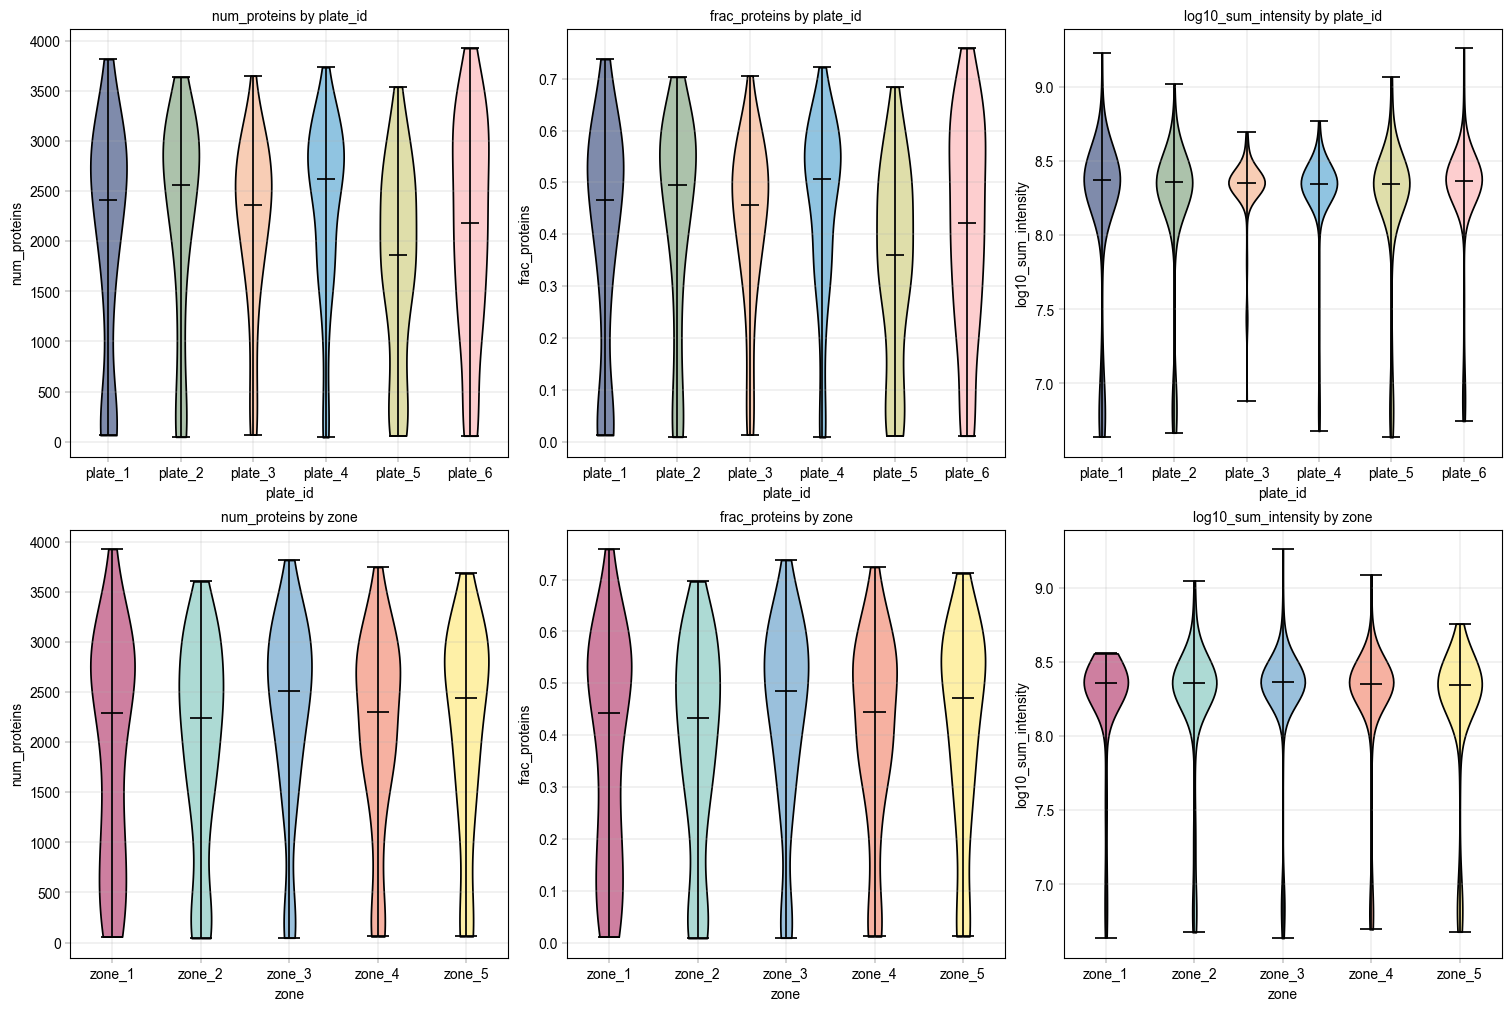

In [ ]:
# Set up figure with subplots: one row per covariate, one column per QC metric
fig, axm = create_figure(2, 3, figsize=(15, 10))

# one row of violinplots
for covariate in [technical, biological]:
    # Order the anndata rows by the technical covariate (alphabetically)
    plate_order = adata.obs[covariate].argsort()
    adata = adata[plate_order, :]

    # decide on color dict
    color_dict = technical_color_dict if covariate == technical else biological_color_dict

    for val in ["num_proteins", "frac_proteins", "log10_sum_intensity"]:
        # skip to next subplot
        ax = axm.next()

        at.pl.Plots.violinplot(
            ax=ax,
            data=adata,
            grouping_column=covariate,
            value_column=val,
            color_dict=color_dict,
        )

        label_axes(ax, title=f"{val} by {covariate}", xlabel=covariate, ylabel=val)

### Observation:

From these plots we can see that the different `plate_id`s (technical covariate) as well as different `zone`s (biological covariate) have similar value distributions. 
All conditions show a "tail" of samples with a lower sum of intensity (1.5 orders of magnitude from median sum, about 30-fold difference) and numbers of proteins. 

### Conclusion:

Given these differences, it might be useful to filter out the samples with especially low `log10_sum_intensity`.  

## 7.2 Visualizing QC Metric Relationships

### Scatter plots of QC metrics help identify:
1. **Outlier samples**: Points far from the main cluster
2. **Batch effects**: Systematic shifts between technical groups
3. **Expected correlations**: Detection and intensity should correlate positively (depending on the upsteam quantification)

### What to Look For:

- **Tight cluster**: Good sample quality and consistency, no sample deviates greatly from the rest of the distribution (outliers)
- **Samples with low detection but high intensity**: Possible poor quality (few proteins dominating)
- **Separation by color (technical groups)**: Batch effects present

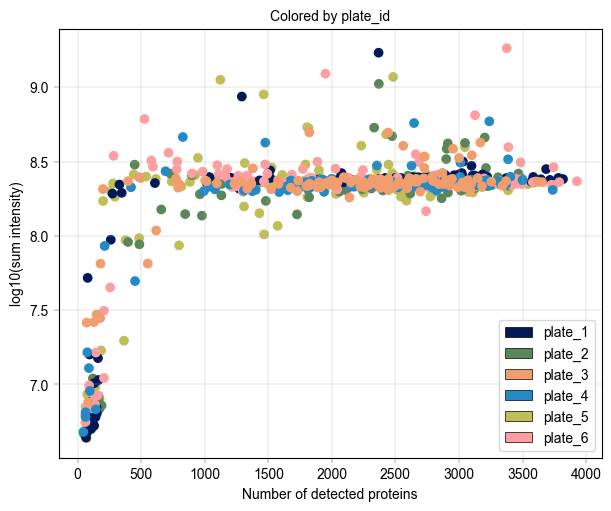

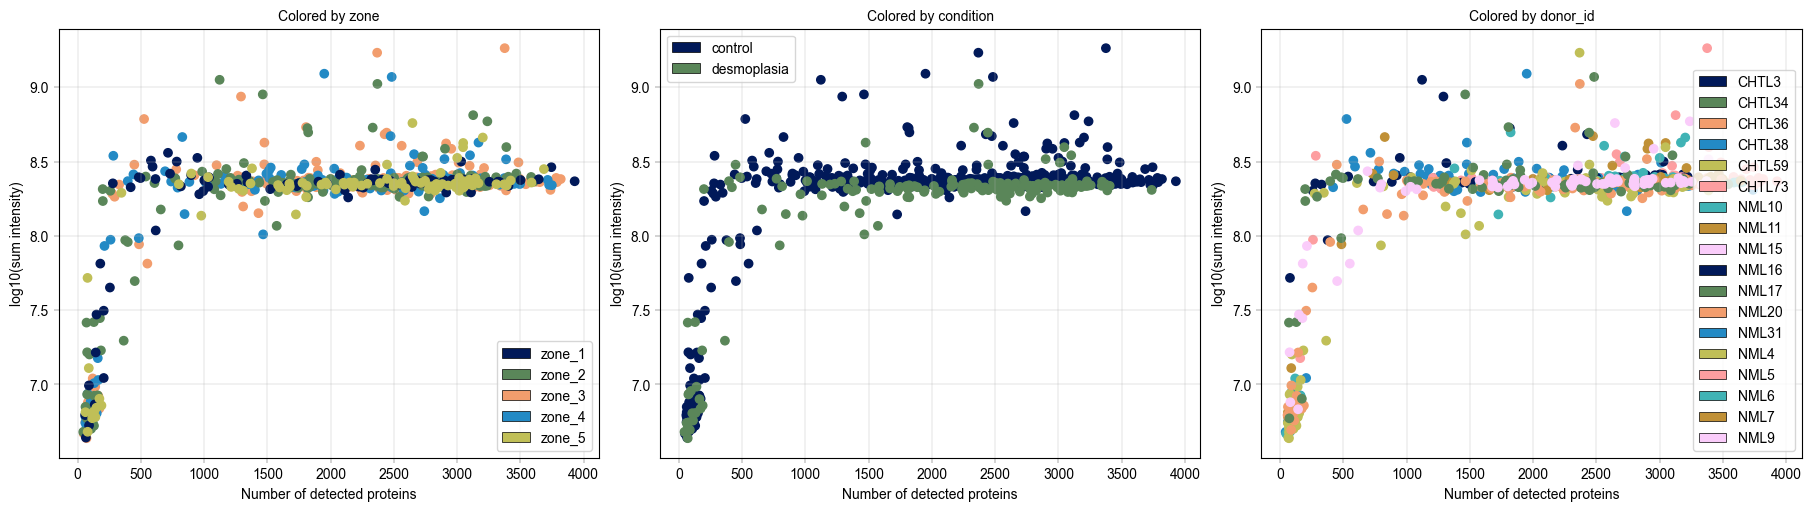

In [ ]:
# Scatter plot: Detection vs Intensity, colored by technical and biological covariates

# Scatter plot for technical covariate
fig, axm = create_figure(1, 1, figsize=(6, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    ax=ax,
    color_map_column=technical,
    legend="auto",
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title=f"Colored by {technical}",
)

# Scatter plots for the biological covariate (color by different columns)
# --> as before, handle the plotting with a small loop over the columns we want to highlight
fig, axm = create_figure(1, 3, figsize=(18, 5))
for color_column in [biological, "condition", "donor_id"]:
    ax = axm.next()
    at.pl.Plots.scatter(
        data=adata.obs,
        x_column="num_proteins",
        y_column="log10_sum_intensity",
        color_map_column=color_column,
        ax=ax,
        legend="auto",
    )
    label_axes(
        ax,
        xlabel="Number of detected proteins",
        ylabel="log10(sum intensity)",
        title=f"Colored by {color_column}",
    )

### Observation:

In this example, we can again notice the cells deviating from the main cluster. These cells have less than 500 detected proteins and lower than 10^8 sum intensity. 

### Conclusion:

Since these cells appear randomly distributed across `condition`, `donor`, `plate` and `zone`, we assume that these are low quality cells rather than an interesting subpopulations or specific batches, increasing our confidence that these cells can be filtered out.

---


## 7.3 Missing Value Analysis

### Understanding Missing Values in Proteomics

Missing values in low input DIA data aquisition are considered to be missing not at random (MNAR), meaning that the missingness is (largly) dependent on the abundance level of the protein  - low-abundance proteins are more likely to be missing. This has been investigated in detail, and an excellent definition / summary and implementation is given in a [paper by Li et al.](https://www.biorxiv.org/content/10.1101/2025.04.28.651125v1.full.pdf) In practice, this means that different missingness patterns may require different imputation strategies. 

### Why This Matters

- **Don't impute blindly**: Simple imputation (e.g., zeros) can distort biological signal
- **Missing patterns can indicate batch effects**: Different batches may have different detection thresholds
- **Filtering may be necessary**: Proteins with too many missing values are unreliable for statistical testing

### Investigating missingness patterns
We can visualize the completeness `1 - fraction of missing values` for each sample, and thereby identify problematic / outlier samples

  adata.obs["sample_rank"] = sample_ranks.to_numpy()



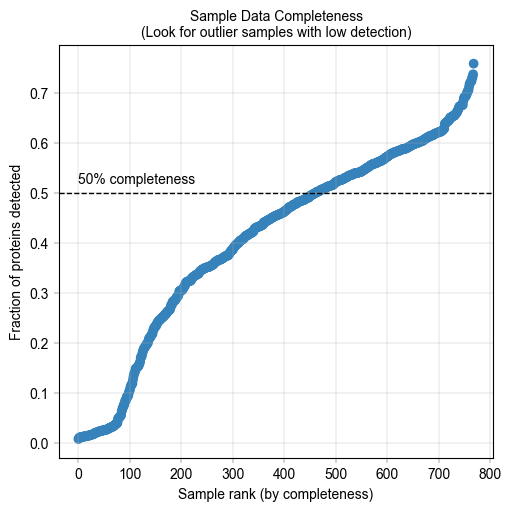

In [ ]:
# Sample completeness: What fraction of proteins does each sample detect?

# Rank samples by completeness
sample_ranks = np.argsort(np.argsort(adata.obs["frac_proteins"]))  # compute ranks
adata.obs["sample_rank"] = sample_ranks.to_numpy()

fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="sample_rank",
    y_column="frac_proteins",
    ax=ax,
)

label_axes(
    ax,
    xlabel="Sample rank (by completeness)",
    ylabel="Fraction of proteins detected",
    title="Sample Data Completeness\n(Look for outlier samples with low detection)",
)

at.pl.add_lines(
    ax,
    intercepts=[0.5],
    linetype="hline",
    linestyle="--",
)

at.pl.label_plot(
    ax,
    x_values=[adata.obs["sample_rank"].min() * 0.7],
    y_values=[0.52],
    labels=["50% completeness"],
)

plt.show()

### Observation:

The plot shows that approximately 50% of the cells have around 50% completeness. This may reflect the overall quality of the samples, consistent with the plot showing the number of detected proteins.

### Conclusion

These plots helped identify some **low-quality samples** with exceptionally few datapoints. We may benefit from removing them, if we can avoid unintentionally removing important groups of samples (e.g., specific conditions or batches). We go about this by estimating an appropriate filtering threshold.

## 7.3.1 Protein-Level Missing Values

Some proteins are detected in all samples ("core proteome"), while others are detected sporadically. Understanding this distribution helps with:

1. **Filtering decisions**: Should we exclude proteins detected in < X% of samples?
2. **Imputation strategies**: Different approaches for different missingness rates
3. **Statistical testing**: Proteins with many missing values have less statistical power

We will plot the distribution of the **protein** completeness (in what fraction of the cells the protein was detected) to get an overview of the proteins.

INFO:root:Column 'frac_expressing_samples' found in: data.var.columns. Using that
INFO:root:Column 'protein_rank' found in: data.var.columns. Using that
INFO:root:Column 'frac_expressing_samples' found in: data.var.columns. Using that


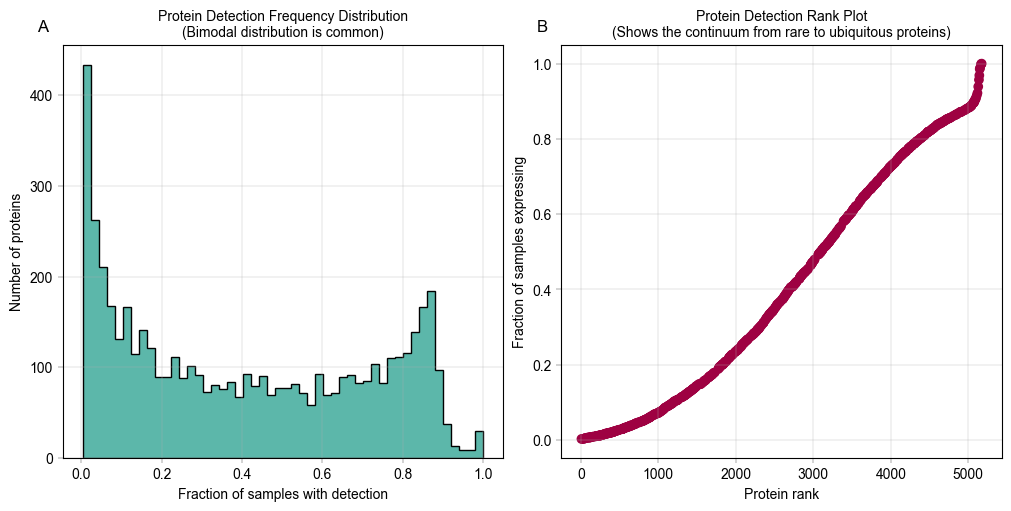

In [ ]:
# Histogram of detection frequency combined with a rank plot
fig, axm = create_figure(1, 2, figsize=(10, 5))

# Protein detection frequency: In how many samples is each protein detected?
adata.var["num_expressing_samples"] = np.sum(~np.isnan(adata.X), axis=0)
adata.var["frac_expressing_samples"] = adata.var["num_expressing_samples"] / adata.n_obs

# Histogram
ax = axm.next()
at.pl.Plots.histogram(
    data=adata,
    value_column="frac_expressing_samples",
    bins=50,
    ax=ax,
    color=BaseColors.get("green"),
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black"},
)

label_axes(
    ax,
    xlabel="Fraction of samples with detection",
    ylabel="Number of proteins",
    title="Protein Detection Frequency Distribution\n(Bimodal distribution is common)",
    enumeration="A",
)

# Rank plot
protein_ranks = np.argsort(np.argsort(adata.var["frac_expressing_samples"]))
adata.var["protein_rank"] = protein_ranks

ax = axm.next()
at.pl.Plots.scatter(
    data=adata,
    x_column="protein_rank",
    y_column="frac_expressing_samples",
    ax=ax,
    color=BaseColors.get("red"),
)
label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Fraction of samples expressing",
    title="Protein Detection Rank Plot\n(Shows the continuum from rare to ubiquitous proteins)",
    enumeration="B",
)

### Observation:

In panel A: We observe a bimodal distribution of proteins, where a large number of proteins is almost never detected, and a second peak shows up for proteins that are very frequently or always detected.
In panel B: There is a steep initial decline from the most detected protein (right), to the least detected ones. Aside from that, the missingness trend appears roughly linear.

### Conclusion

Most proteins are not consistently detected across all samples. Instead, protein detection varies between samples, likely reflecting underlying biological variability, where differences in cellular composition, physiological states, or regulatory activity result in distinct protein detection patterns across samples. Nonetheless, proteins detected in only a small fraction of samples may introduce technical noise and contribute limited analytical value due to their sparsity. Therefore, filtering proteins with low detection or completion rates can improve data robustness.

## 7.3.1 Missing Values vs. Abundance

This is a key diagnostic plot in proteomics QC. It demonstrates that missing values are **not random** - they correlate with protein abundance.
This can help us asses the more "reliable" abundance levels, in which most of the proteins are above detection limit in most of the samples.

**Expected pattern:** Low-abundance proteins have more missing values (MNAR behavior)

**Implications:**
- Statistical tests should account for this systematic missingness
- Consider abundance-aware imputation methods if imputation is necessary

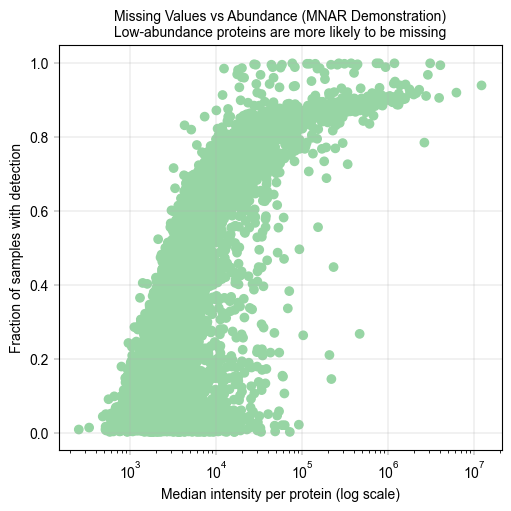

In [ ]:
# Missing fraction vs median intensity per protein
# This plot demonstrates the MNAR (Missing Not At Random) nature of proteomics data
fig, axm = create_figure(1, 1, figsize=(5, 5))

median_intensity_per_protein = np.nanmedian(adata.X, axis=0)
adata.var["median_intensity"] = median_intensity_per_protein

# Log plot
ax = axm.next()
at.pl.Plots.scatter(
    data=adata.var,
    x_column="median_intensity",
    y_column="frac_expressing_samples",
    color=BaseColors.get("lightgreen"),
    ax=ax,
)
ax.set_xscale("log")
label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)

### Observation:

Proteins show a correlation between missingness and median intensity.

### Conclusion:

Our missing values appear to be not entirely random, but correlated to the protein abundance. This is in line with [literature](https://www.biorxiv.org/content/10.1101/2025.04.28.651125v1.full.pdf), and represents a key feature of proteomics and especially low-input proteomics.

## 7.3.2 Missing values section conclusions

In this section, we examined the distribution of proteins across samples and the relationship between missing values and intensity levels. These plots provide insight into dataset completeness and help guide the selection of thresholds for protein filtering based on completeness.

In the following sections (Sections 11 and 12, covering sample and protein filtering, respectively), we provide practical guidelines for setting filtering thresholds informed by the patterns observed in these analyses.

---

## 8. Intensity Distribution Analysis

A hallmark feature of proteomics is the high dynamic range in the intensity of detected features. In regular expression proteomics datasets, spanning 5+ orders of magnitude is common.

## 8.1 Rank-Abundance Plot

The rank-abundance (or "rank-median") plot shows the dynamic range of protein abundances. Proteins are ranked by their median intensity across samples.

**What it reveals:**
- **Dynamic range**: How many orders of magnitude does protein abundance span?
- **Dominant proteins**: A few highly abundant proteins often dominate the proteome
- **Detection limit**: The "tail" shows the low end of detection

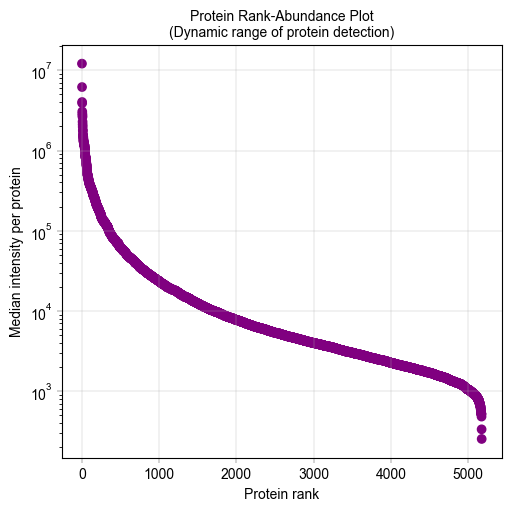

In [ ]:
# Rank-median plot: Shows the dynamic range of protein abundances
fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

# Add rank to protein dataset and reorder proteins by median intensity
adata = adata.copy()
adata.var["protein_rank"] = np.argsort(np.argsort(-adata.var["median_intensity"]))  # negative sign for descending order

# Simple median rank plot
at.pl.Plots.scatter(
    ax=ax, data=adata.var, x_column="protein_rank", y_column="median_intensity", color=BaseColors.get("purple")
)
ax.set_yscale("log")

label_axes(
    ax,
    xlabel="Protein rank",
    ylabel="Median intensity per protein",
    title="Protein Rank-Abundance Plot\n(Dynamic range of protein detection)",
)

### Observation:

This plot shows what fraction of total intensity is contributed by the top N proteins.

### Conclusion:

In most proteomics datasets, a small fraction of proteins contributes the majority of the signal. This should be taken into account when considering normalization to the sum or to the median.


### **What to look for:**
- **Steep initial rise**: Few proteins dominate the proteome (typical)
- **Similar curves across samples**: Consistent sample preparation
- **Outlier curves**: May indicate sample quality issues

## 8.2 Cumulative signal plot

The differences spanning several orders of magnitude indicate that a small number of highly abundant proteins contribute disproportionately to the total intensity sum of each sample, whereas the majority of proteins contribute relatively little. As a result, highly abundant proteins can mask meaningful differences between samples. By separating these proteins from the overall intensity sum, we can better evaluate the global protein expression behavior of each sample rather than focusing primarily on a few dominant proteins.

In the following sections, we will examine the cumulative intensity distribution of proteins within samples to assess whether tens to hundreds of proteins account for more than 80% of the total intensity. We will also identify outlier samples in which only a small number of proteins contribute to this fraction, which may indicate reduced sample quality. Additionally, we will quantify the combined intensity of proteins excluding the most abundant ones and compare these values to the total intensity and across samples to help identify potential outliers.

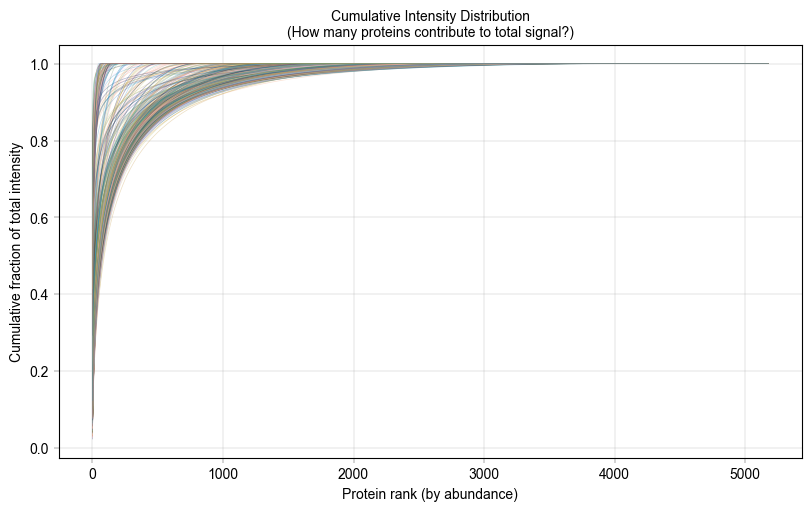

In [ ]:
# Cumulative intensity distribution per sample
# Shows how total signal is distributed across proteins

fig, axm = create_figure(1, 1, figsize=(8, 5))
ax = axm.next()

# Create zero-filled layer for cumulative sum calculation
adata.layers["zero_filled"] = adata.X.copy()
adata.layers["zero_filled"][np.isnan(adata.layers["zero_filled"])] = 0

for i in range(adata.layers["zero_filled"].shape[0]):
    sample_values = adata.layers["zero_filled"][i, :].flatten()
    sorted_values = np.sort(sample_values)[::-1]
    cumsum_values = np.cumsum(sorted_values)
    cumsum_values /= cumsum_values[-1]  # normalize to total intensity (=1)
    ax.plot(cumsum_values, alpha=0.3, linewidth=0.5)

label_axes(
    ax,
    xlabel="Protein rank (by abundance)",
    ylabel="Cumulative fraction of total intensity",
    title="Cumulative Intensity Distribution\n(How many proteins contribute to total signal?)",
)
# ax.set_ylim(0, 1)
plt.show()

### Observation

Here we see that most cells show a steep curve, with 80% of the sum gained about after 200-500 proteins, and some cells shoot up close to 100% of the sum intensity after only a few proteins. 

### Conclusion

Cells that reach nearly their full sum intensity after a handful of proteins might be poor quality measurements.

## 8.3 Exclude highly abundant proteins

It is common in transcriptomics to exclude highly expressed genes from normaliztion calculations. By focusing on proteins which account for less than 10% of sum intensity, we can observe if there are differences in the sum intensities of the other proteins in the samples (otherwise obscured by the high level proteins).

INFO:root:Column 'num_proteins' found in: data.obs.columns. Using that
INFO:root:Column 'log_sum_intensity_filtered' found in: data.obs.columns. Using that
INFO:root:Column 'log10_sum_intensity' found in: data.obs.columns. Using that


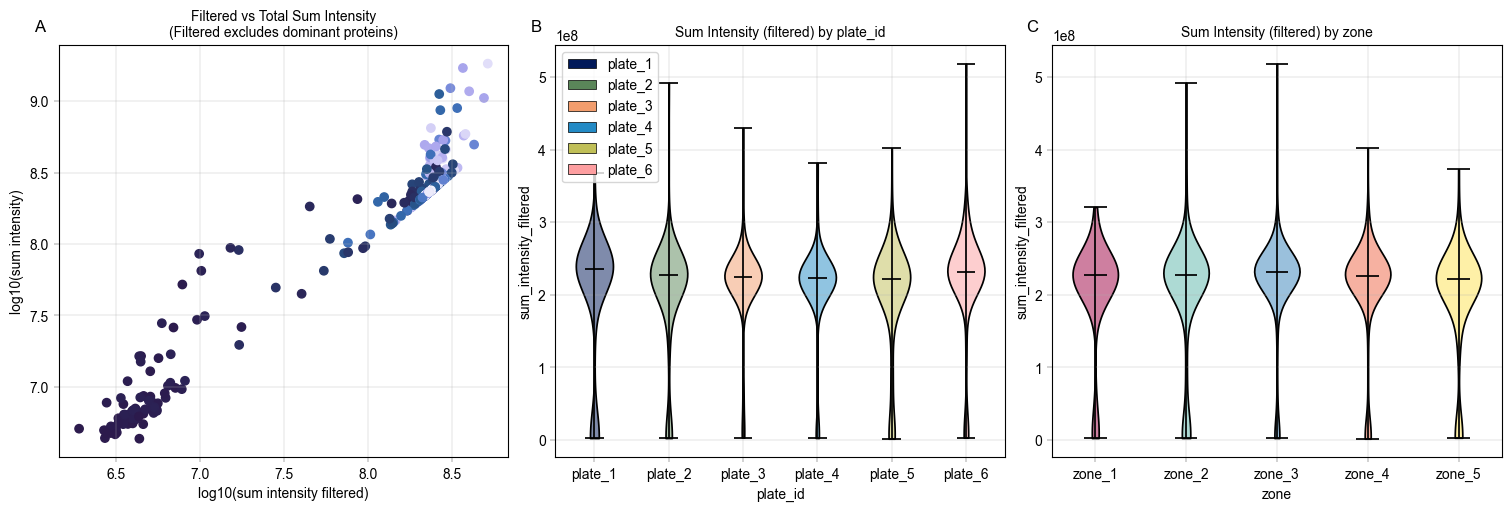

In [ ]:
# Calculate sum intensity per sample, excluding genes > 20% of total
def sum_excluding_dominant(row: np.ndarray, pc: float) -> float:
    """
    Calculate sum intensity excluding dominant proteins.

    Sums only proteins that contribute less than 10% of total intensity,
    useful for detecting quality differences obscured by highly abundant proteins.
    Args:
        row: Array of protein intensities for a sample
        pc: Proportion cutoff to define dominant proteins
    Returns:
        Sum of intensities for non-dominant proteins
    """
    total = np.nansum(row)
    if total == 0 or np.isnan(total):
        return 0.0
    # Keep only genes contributing < 10% of total
    fractions = row / total
    mask = fractions < pc
    return float(np.nansum(row[mask]))


# Apply to each sample (row)
adata.obs = adata.obs.copy()
adata.obs["sum_intensity_filtered"] = np.apply_along_axis(sum_excluding_dominant, axis=1, arr=adata.X, pc=0.1)
adata.obs["log_sum_intensity_filtered"] = np.log10(adata.obs["sum_intensity_filtered"])

fig, axm = create_figure(1, 3, figsize=(15, 5))

ax = axm.next()
at.pl.Plots.scatter(
    data=adata,
    x_column="log_sum_intensity_filtered",
    y_column="log10_sum_intensity",
    color_map_column="num_proteins",
    palette=BaseColormaps.get("sequential"),
    ax=ax,
    legend="auto",
)
label_axes(
    ax,
    xlabel="log10(sum intensity filtered)",
    ylabel="log10(sum intensity)",
    title="Filtered vs Total Sum Intensity\n(Filtered excludes dominant proteins)",
    enumeration="A",
)

for enumerator, covariate in zip("BC", [technical, biological], strict=False):
    # Create an ordered view of the anndata rows by the technical covariate (alphabetically)
    plate_order = adata.obs[covariate].argsort()
    adata_ordered = adata[plate_order, :]

    # decide on color dict
    color_dict = technical_color_dict if covariate == technical else biological_color_dict

    # skip to next subplot
    ax = axm.next()

    at.pl.Plots.violinplot(
        ax=ax,
        data=adata_ordered,
        grouping_column=covariate,
        value_column="sum_intensity_filtered",
        color_dict=color_dict,
    )

    if covariate == technical:
        at.pl.add_legend_to_axes(
            ax,
            levels=technical_color_dict,
        )

    label_axes(
        ax,
        title=f"Sum Intensity (filtered) by {covariate}",
        xlabel=covariate,
        ylabel="sum_intensity_filtered",
        enumeration=enumerator,
    )

### Observation:

Panel A shows an overall (expected) positive correlation between the total intensity sum and the filtered intensity sum. However, several samples deviate from the diagonal, exhibiting disproportionately higher total intensity relative to the filtered sum. Coloring by the number of detected proteins indicates that this effect cannot be fully explained by differences in sample completeness alone. Panels B and C demonstrate that the distributions of filtered intensity sums are comparable across all plates (Panel B) and zones (Panel C), with low-intensity outliers are present under all conditions, likely reflecting lower-quality samples.

### Conclusion:

The fact that a small number of proteins account for the majority of the total sample intensity is not observed in RNA sequencing, which may partly explain why standard normalization methods used in RNA-seq are often not suitable for mass spectrometry data. Evaluating sample-level metrics that exclude highly abundant proteins provides a more informative view of technical variation between samples and can aid in identifying potential quality issues.

---


## 9. Coefficient of Variation (CV) Analysis

### What is CV?

The **Coefficient of Variation** measures relative variability:

$$CV = \frac{\text{Standard Deviation}}{\text{Mean}} \times 100\%$$

### Considertions for CVs in proteomics

- Lower CV = more reproducible measurements
- Technical replicates should have CV < 20% (empirical threshold for tolerable workflow imprecision)

### Common practice in CV evaluation 

| CV Range | Interpretation |
|----------|----------------|
| < 10% | Excellent reproducibility |
| 10-30% | Good, typical for biological replicates |
| 30-50% | Acceptable for some applications |
| > 50% | High variability, interpret with caution |

Note: These CV ranges represent commonly used benchmarks in the field rather than strict or universally accepted thresholds, and should be interpreted in the context of the experimental design and data quality.

### CV vs abundance

Low-abundance proteins typically have higher CV due to:
- Measurement noise is larger relative to signal
- Stochastic sampling effects
- Near-detection-limit variability

This relationship is known and important; [some imputation methods](https://www.biorxiv.org/content/10.1101/2025.04.13.648568v1) try to consider this relationship of variance & abundance in the way they model missing values.


Because this dataset includes cells derived from different individuals, defining true technical replicates is not straightforward, as variability within a given group may reflect biological differences rather than technical noise. Nevertheless, it is reasonable to expect that variability within more homogeneous groups (e.g., within each zone and donor) would be lower than the overall variability across the entire dataset. In the following section, we will calculate and visualize protein CVs across all conditions as well as within each zone and donor and compare the results.

In [ ]:
# Calculate CV for each protein using alphapepttools
at.metrics.coefficient_of_variation(
    adata,
    key_added="CV",
    min_valid=3,
)

# inspect CV values
display(adata.var[["CV"]].head(10))

,CV
uniprot_ids,
A0A024R1R8;Q9Y2S6,0.443208
A0A075B6H7;A0A0C4DH55;P01624,1.191872
A0A075B6I0,0.753994
A0A075B6K4,1.413635
A0A075B6K5,0.997619
A0A075B6P5;P01615,1.145592
A0A075B6R9;A0A0C4DH68,0.880623
A0A087WSY6,0.963347
A0A0A0MRZ8;P04433,1.716892


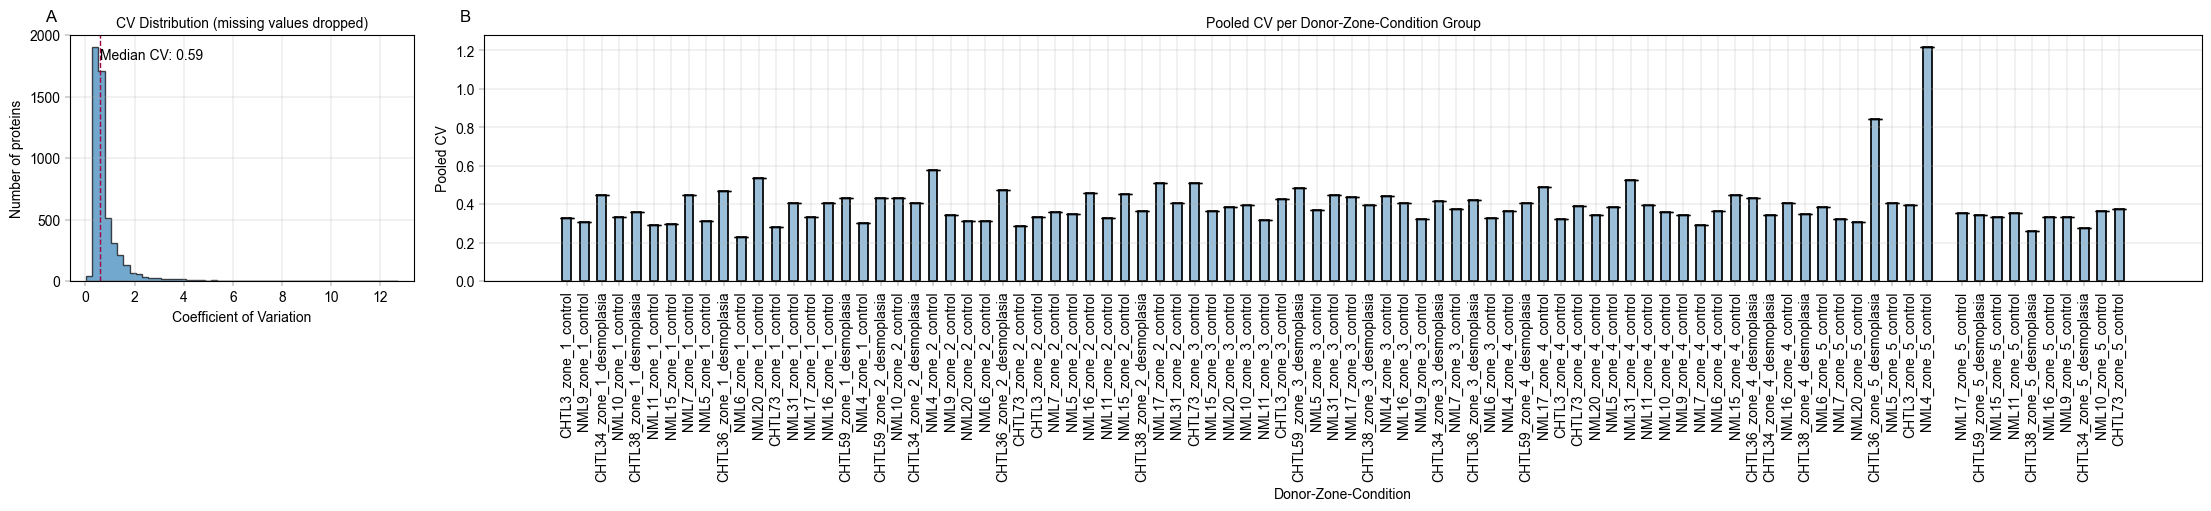

In [ ]:
# CV distribution histogram
# make right window twice the width
fig, axm = create_figure(1, 2, figsize=(22, 5), gridspec_kwargs={"width_ratios": [1, 5]})

# Show the CV distribution across all proteins, disregarding replicates
ax = axm.next()
at.pl.Plots.histogram(
    data=adata.var,
    value_column="CV",
    bins=50,
    ax=ax,
    hist_kwargs={"histtype": "stepfilled", "edgecolor": "black", "alpha": 0.7},
)

median_cv = adata.var["CV"].median()

at.pl.add_lines(
    ax,
    intercepts=[median_cv],
    linetype="vline",
    linestyle="--",
    color=BaseColors.get("red"),
)

at.pl.label_plot(
    ax,
    x_values=[median_cv + 0.02],
    y_values=[ax.get_ylim()[1] * 0.9],
    labels=[f"Median CV: {median_cv:.2f}"],
)

label_axes(
    ax,
    xlabel="Coefficient of Variation",
    ylabel="Number of proteins",
    title="CV Distribution (missing values dropped)",
    enumeration="A",
)

# Focus on individual replicates: CV per protein in each donor_id - zone - condition group
adata.obs = adata.obs.copy()
adata.obs["donor_zone_condition"] = (
    adata.obs["donor_id"].astype(str) + "_" + adata.obs["zone"].astype(str) + "_" + adata.obs["condition"].astype(str)
)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    pooled_cvs = at.metrics.pooled_coefficient_of_variation(
        adata,
        group_key="donor_zone_condition",
        min_valid=3,
        inplace=False,
    )

if "pcv" not in adata.obs.columns:
    adata.obs = adata.obs.copy()
    adata.obs = adata.obs.merge(
        pooled_cvs,
        left_on="donor_zone_condition",
        right_index=True,
        how="left",
    )

ax = axm.next()
at.pl.Plots.barplot(
    ax=ax,
    data=adata,
    grouping_column="donor_zone_condition",
    value_column="pcv",
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")

label_axes(
    ax,
    title="Pooled CV per Donor-Zone-Condition Group",
    xlabel="Donor-Zone-Condition",
    ylabel="Pooled CV",
    enumeration="B",
)

plt.show()

### Observation:

Median CV without considering replicates is high (59 %), but a more differentiated picture emerges when individual treatment groups are plotted. It seems that NML4 zone 5 control and CHTL36 zon 5 desmoplasia samples suffer from unusually high CVs, which may warrant their exclusion.

### Conclusion:

Collective CVs are rather uninformative, but group-wise CVs per replicate identify problematic entries.


---



## 9.1 CV vs. mean 

We saw that the CV is used to assess reproducibility and stability of the data when chacked **across replicates**. 
Between different biological/experimetal groups, high CV can indicate that these proteins are differentially expressed. 
Also, highly variable proteins are the main drivers of many downstream analyses (such as PCA and clustering). Therefore, it is useful to check the protein variabilty. To do so, we can plot the CV against the mean abundance. In proteomics, we usually expect a negative correlation, that is high CV <=> lower mean, indicating that the lowest abundant proteins are also the most variable ones.
Since NaN values should not be dropped in this analysis (dispersion also depends on the number of samples), we will assign minimal value to NaNs and calculate the CV and mean on that.  

### In the following analysis,
We visualize protein CV vs. mean, which enables us to spot especially variable outliers. Contaminant proteins that are present in some replicates can show up in such an analysis. For example, plasma proteomics is [sensitive to incorrect sample processing](https://www.biorxiv.org/content/10.1101/2025.05.07.652495v1.abstract), which can enrich some samples with unwanted proteins from blood cells. Unless contamination is uniform across all replicates, the contaminants would show up as high-CV outliers in an analysis such as the one below.

**What it can help us with:**
 - compare those proteins with our biological assumptions/expectations from the dataset 
 - identify potential highly variable contaminants
 - estimate abundance levels of technical noise




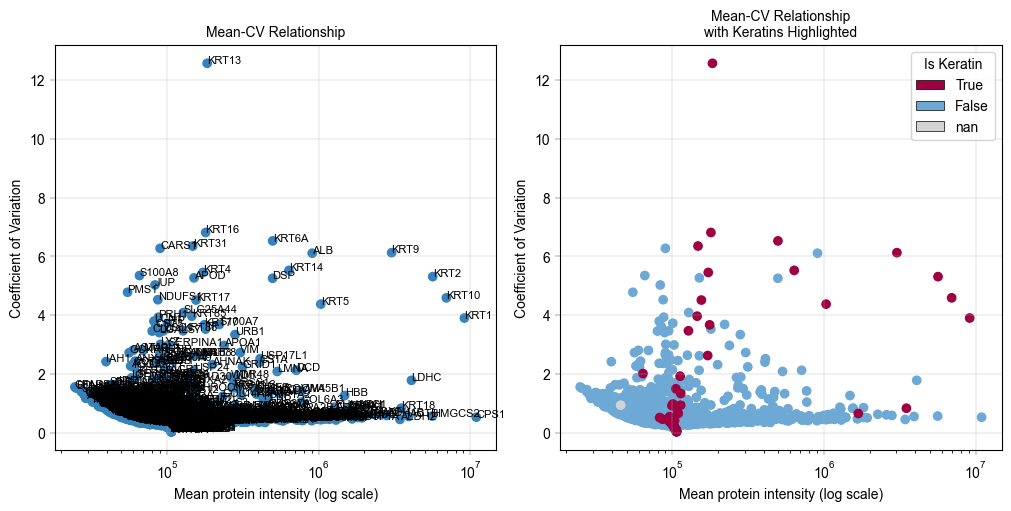

In [ ]:
# Since we operate on the .X object, we first store away the original values in a separate layer
adata.layers["orig_intensity"] = adata.X.copy()

# Mean-CV relationship (classic proteomics QC plot)
MIN = np.nanmean(adata.X)
adata.X[np.isnan(adata.X)] = MIN

# calculate CV and mean with imputed missing values
at.metrics.coefficient_of_variation(adata, key_added="CV_imp", min_valid=3)
adata.var["protein_mean_imp"] = np.nanmean(adata.X, axis=0)

# Set .X back to original values
adata.X = adata.layers["orig_intensity"].copy()

# Create a two-panel figure to showcase the CV vs Mean relationship
fig, axm = create_figure(1, 2, figsize=(10, 5))
ax = axm.next()

# First, label everything
at.pl.Plots.scatter(
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    ax=ax,
)

ax.set_xscale("log")

adata.var["single_gene_name"] = adata.var["Genes"].str.split(";").str[0].copy()

at.pl.label_plot(
    ax=ax,
    x_values=adata.var["protein_mean_imp"],
    y_values=adata.var["CV_imp"],
    labels=adata.var["single_gene_name"],
    label_kwargs={"fontsize": 8},
)

label_axes(
    ax, xlabel="Mean protein intensity (log scale)", ylabel="Coefficient of Variation", title="Mean-CV Relationship"
)

# Second, focus on keratin proteins
adata.var["is_keratin"] = adata.var["single_gene_name"].str.contains("KRT")

ax = axm.next()
at.pl.Plots.scatter(
    data=adata.var,
    x_column="protein_mean_imp",
    y_column="CV_imp",
    ax=ax,
    color_map_column="is_keratin",
    color_dict={True: BaseColors.get("red"), False: BaseColors.get("lightblue")},
    legend="auto",
    legend_kwargs={"title": "Is Keratin"},
)

ax.set_xscale("log")

label_axes(
    ax,
    xlabel="Mean protein intensity (log scale)",
    ylabel="Coefficient of Variation",
    title="Mean-CV Relationship\nwith Keratins Highlighted",
)

### Observation:

This plot highlights the highly variable proteins (HVPs) in the dataset. In this example, Keratins (KRT) appear among the HVPs. 

### Conclusion:

Since Keratins are known contaminants, they can be considered for removal in downstream analyses, particularly PCA, because we are not interested in variability driven by contamination.

---


## 10. Detailed sanity checks using individual proteins

If there are **known biological markers** or **expected patterns**, checking their distributions is a good and fast way to test how well the data meet the biological expections from existing knowledge. This kind of sanity check is an essential counterpart to technical QC metrics, since a well-executed sample preparation and measurement is independent from the validity of the biological study setup.

**For liver peotein zonation data, we expect:**
- **CYP2E1, GLUL**: Central zone markers, should be higher in zone 5 and gradually decreasing.
- **CPS1, ASS1**: Periportal markers, should be higher in zone 1 and gradually decreasing.

**What to check:**
1. Do known markers show expected biological patterns?
2. Are distributions similar across technical batches (after accounting for biology)?

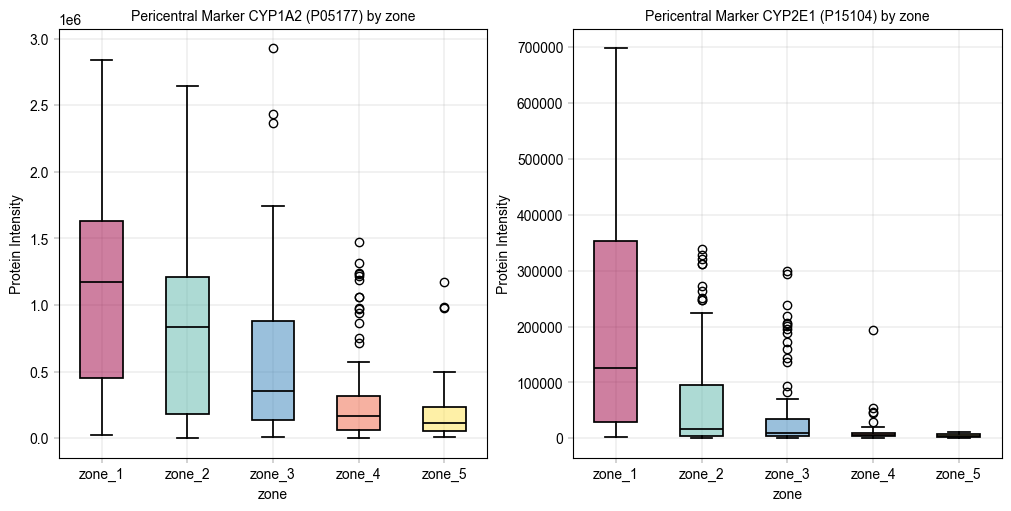

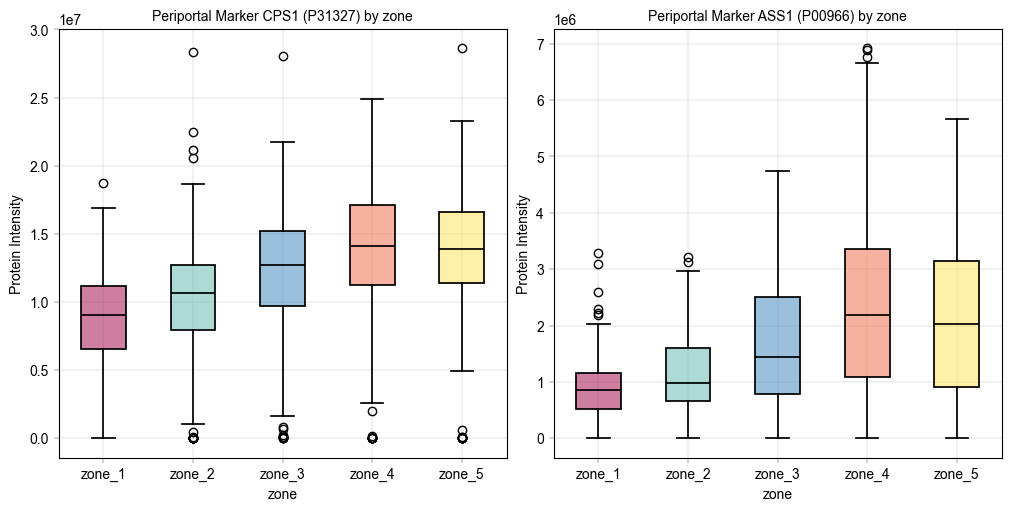

In [ ]:
# Check distribution of known marker proteins

pericentral = {"P05177": "CYP1A2", "P15104": "CYP2E1"}  # CYP1A2, CYP2E1
periportal = {"P31327": "CPS1", "P00966": "ASS1"}  # CPS1, ASS1

# Set up plots to visualize marker proteins with boxplots
fig, axm = create_figure(1, 2, figsize=(10, 5))
for pericentral_marker, pericentral_marker_gene in pericentral.items():
    # Get the corresponding column slice
    adata_pericentral = adata[:, [pericentral_marker]]

    # Order by biological covariate
    bio_order = adata_pericentral.obs[biological].argsort()
    adata_pericentral = adata_pericentral[bio_order, :]

    ax = axm.next()
    at.pl.Plots.boxplot(
        ax=ax,
        data=adata_pericentral,
        grouping_column=biological,
        value_column=pericentral_marker,
        color_dict=biological_color_dict,
    )

    label_axes(
        ax,
        title=f"Pericentral Marker {pericentral_marker_gene} ({pericentral_marker}) by {biological}",
        xlabel=biological,
        ylabel="Protein Intensity",
    )

fig, axm = create_figure(1, 2, figsize=(10, 5))
for periportal_marker, periportal_marker_gene in periportal.items():
    # Get the corresponding column slice
    adata_periportal = adata[:, [periportal_marker]]

    # Order by biological covariate
    bio_order = adata_periportal.obs[biological].argsort()
    adata_periportal = adata_periportal[bio_order, :]

    ax = axm.next()
    at.pl.Plots.boxplot(
        ax=ax,
        data=adata_periportal,
        grouping_column=biological,
        value_column=periportal_marker,
        color_dict=biological_color_dict,
    )

    label_axes(
        ax,
        title=f"Periportal Marker {periportal_marker_gene} ({periportal_marker}) by {biological}",
        xlabel=biological,
        ylabel="Protein Intensity",
    )

### Observation:

For these markers we could observe the expected patterns. An especially good sign is that these patterns show up even before filtering data, which alludes to a core tenet in proteomics analyses: In our experience, strong biological signal is always there and only enhanced by filtering / preprocessing. If a study fails to meet critical biological assumptions from the get-go, it is a sign to interpret the data with caution. And sanity check the experimental setup and workflow to ensure that the data at hand is plausible.

### Conclusion:

Since key markers show expected trends across the biological covariate `zone`, we assume that the data is in principle trustworthy and that valid conclusions can be drawn in further analyses.

---

## 11. Data Filtering

### Filtering Philosophy
Filtering involves a trade-off between losing datapoints and removing technical noise, both of which can affect downstream statistical analyses. Typically, the filtering threshold is set based on the QC plots and the experimental design (e.g., number of samples) and overall data quality. But how stringent should the thresholds be? In their [scRNA-seq tutorial](https://doi.org/10.15252/msb.20188746), Luecken and Theis (2019) recommend an iterative approach: start with a permissive threshold and adjust it downward if downstream analyses reveal technical artifacts. This strategy is also appropriate in the current context. 

### Sample Filtering
Following the manuscript methodology & with our preceding analyses in mind, we:
- remove samples with very low protein detection
- remove outliers identified in QC plots
- ensure each condition/zone has sufficient representation


## 11.1 Removing sample outliers

For sample filtering, we orient ourselves on the manuscript, where Z scores of the number of proteins detected per sample were used to label outliers. Importantly, we introduce a small change, and use MAD (median absolute deviation) to calculate a non-parametric
equivalent of the Z-score, which is considered to be more robust, as suggested by Heumos et al. in their [multi-modal single cell best practices](https://doi.org/10.1038/s41576-023-00586-w). Taking this into account, we can define outliers for our analysis:

- "An outlier is a sample with a MAD-score above 3 or below -3"

These cutoff values sreve as general guidelines and are not fixed. Thresholds should be adjusted based on the distribution and characteristics of the dataset.

For the calculation, we replace the _mean_ and _standard deviation_ in the z-score formula with the _median_ and the _median absolute deviation_. Therefore,

$$\text{z-score} = \frac{\text{value} - \text{mean}}{\text{std}}$$

becomes

$$\text{MAD-score} = \frac{\text{value} - \text{median}}{\text{MAD}}$$

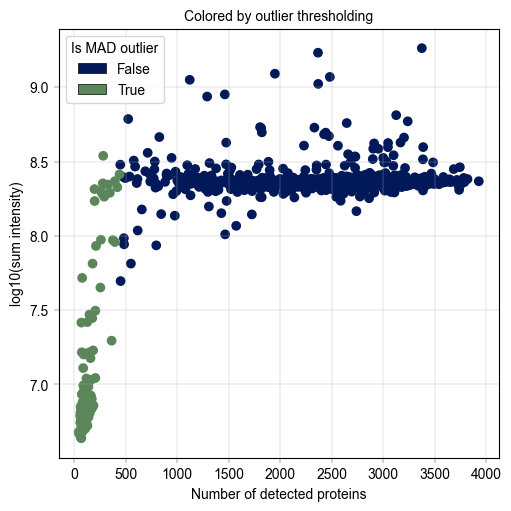

In [ ]:
# Calculate the median absulte deviation (MAD) for the number of detected proteins

# First, compute the median protein count across all samples (scalar)
median_proteins = np.median(adata.obs["num_proteins"])

# Second, compute the absolute deviation from the median for each sample (vector, we use this instead of subtracting the mean as we would for z-scores)
adata.obs["sample_absolute_deviation"] = np.abs(adata.obs["num_proteins"] - median_proteins)

# Third, compute the median of these deviations (actual MAD statistic, scalar, which we use instead of std)
mad_proteins = np.median(adata.obs["sample_absolute_deviation"])

# Fourth, compute MAD-normalized score (similar to z-score but using median/MAD instead of mean/std)
adata.obs["num_proteins_MAD"] = (adata.obs["num_proteins"] - median_proteins) / mad_proteins

# mark outliers
LOW = -3
HIGH = 3
adata.obs["is_outlier"] = (adata.obs["num_proteins_MAD"] < LOW) | (adata.obs["num_proteins_MAD"] > HIGH)

# Plot proteins that are outliers according to MAD thresholding
fig, axm = create_figure(1, 1, figsize=(5, 5))

ax = axm.next()
at.pl.Plots.scatter(
    data=adata.obs,
    x_column="num_proteins",
    y_column="log10_sum_intensity",
    color_map_column="is_outlier",
    ax=ax,
    legend="auto",
    legend_kwargs={"title": "Is MAD outlier"},
)
label_axes(
    ax,
    xlabel="Number of detected proteins",
    ylabel="log10(sum intensity)",
    title="Colored by outlier thresholding",
)

### Observation:

A small fraction of samples has critically few detected proteins, whcih also coincides with much (up to more than one order of magnitude) lower sum intensity.

### Conclusion:

We decide to remove these outlier samples and keep samples with roughly constant intensity and protein detection numbers

In [ ]:
# filter out the outlier samples (number of detected proteins should be independent of condition, therefore we apply a single threshold here)
adata_filtered = adata[~adata.obs["is_outlier"], :].copy()
print(f"Remaining samples before outlier removal: {adata.n_obs}")
print(f"Remaining samples after outlier removal: {adata_filtered.n_obs}")

Remaining samples before outlier removal: 769
Remaining samples after outlier removal: 677


Additionally, we focus on control condition samples for further analysis:

In [ ]:
adata_filtered = adata_filtered[adata_filtered.obs["condition"] == "control", :]

## 12. Protein Filtering

Similar to sample filtering, protein filtering requires defining an appropriate threshold for protein inclusion. Typically, proteins detected in only a small fraction of samples are removed. However, this threshold should account for dataset heterogeneity, as it may not be realistic to expect all proteins to be detected across all samples. A practical strategy is to begin with a relatively permissive threshold (e.g., retaining proteins detected in at least 20% of samples) and then iteratively apply more stringent cutoffs to evaluate their impact on the analysis.

Following the manuscript: "...an additional filtering criterion at the protein level was applied, requiring proteins to be detected in at least 70% of samples..." - we will apply the same threshold here.
Based on the QC plots, this threshold would remove more than 50% of the proteins. Alternative approaches include using less stringent thresholds and iteratively adjust according to downstream evaluations, or applying imputation. Even when imputation is used, it is still recommended to remove proteins with very low coverage.

**Why this threshold?**
- Reduces noise from sporadic detections
- Creates a reliable "proteome" for downstream analyses



  adata_filtered.var["frac_expressing_samples"] = np.sum(~np.isnan(adata_filtered.X), axis=0) / adata_filtered.n_obs

INFO:root:pp.filter_data_completeness(): flag 3519 / 5175 features with >0.30 missing in any group.


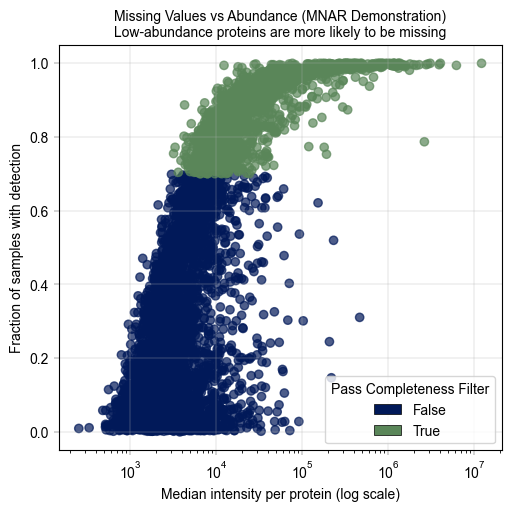

In [ ]:
# Recalculate data completeness per protein as the fraction of samples with non-missing values in the filtered dataset
adata_filtered.var["frac_expressing_samples"] = np.sum(~np.isnan(adata_filtered.X), axis=0) / adata_filtered.n_obs

# By running data completeness filtering with the 'flag' action, we can see which proteins would be filtered out at a given threshold
adata_filtered = at.pp.filter_data_completeness(
    adata_filtered, max_missing=0.3, action="flag", var_colname="pass_completeness_filter"
)

# Visualize removed proteins based ontheir median intensity
fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

at.pl.Plots.scatter(
    data=adata_filtered.var,
    x_column="median_intensity",
    y_column="frac_expressing_samples",
    color_map_column="pass_completeness_filter",
    legend="auto",
    ax=ax,
    legend_kwargs={"title": "Pass Completeness Filter"},
    scatter_kwargs={"alpha": 0.7},
)

ax.set_xscale("log")

label_axes(
    ax,
    xlabel="Median intensity per protein (log scale)",
    ylabel="Fraction of samples with detection",
    title="Missing Values vs Abundance (MNAR Demonstration)\nLow-abundance proteins are more likely to be missing",
)

In [ ]:
# now we filter the proteins to keep only those detected in 70% of samples
print(f"Proteins before filtering for 70% completeness: {adata_filtered.n_vars}")
adata_filtered = at.pp.filter_data_completeness(adata_filtered, max_missing=0.3, action="drop")
print(f"Remaining proteins after filtering for 70% completeness: {adata_filtered.n_vars}")

INFO:root:pp.filter_data_completeness(): drop 3519 / 5175 features with >0.30 missing in any group.


Proteins before filtering for 70% completeness: 5175
Remaining proteins after filtering for 70% completeness: 1656


---

## 13. Dimensionality Reduction & Variance Analysis

## 13.1 PCA in Proteomics

PCA reveals the **major sources of variance** in your data. In a well-designed experiment:
- **Ideal**: Samples cluster by biological condition (zonation)
- **Problematic**: Samples cluster by technical factor (donor, plate)

### What good results look like
- Samples from same biological group cluster together
- Technical replicates are closer to each other than to other samples.

### Warning signs
- Samples cluster by batch/donor instead of biology
- Single outlier samples far from main cluster
- No clear structure (random scatter)

### Expected zonation pattern
For liver data, we expect a zonation gradient along the first PCs (usually apparent on PC1)
If PCA separates zones → biological signal preserved.

### Core Proteome for PCA

For 'vanilla' PCA, we require a complete data matrix, i.e. proteins with no missing values. Aside from imputation, filtering for the 'core proteome' accomplishes that by removing all proteins whcih have any missing values.

### Contaminant flagging
As we saw in previous figures, common proteomics contaminants are highly variable in the dataset:
- **Keratins (KRT*)**: Skin contamination from sample handling
- **Serum albumin (ALB)**: Often dominates signal, may mask other proteins
- **Hemoglobin (HB*) and immunoglobulins**: Blood contamination

We further exclude these from PCA (even if they are present in the "core proteome") as we are not interested in their variability, but keep them for total intensity calculations.


In [ ]:
# Define core proteome: proteins detected in all samples, excluding contaminants

# Flag proteins with no missing values
adata_filtered = at.pp.filter_data_completeness(adata_filtered, max_missing=0, action="flag", var_colname="is_core")

# Remove proteins outside the core proteome and known contaminants using AnnData's filtering capabilities
adata_filtered.var["prot_for_pca"] = (
    adata_filtered.var["is_core"]
    & ~(adata_filtered.var["Genes"].str.startswith("KRT", na=False))
    & ~(adata_filtered.var["Genes"].str.startswith("ALB", na=False))
    & ~(adata_filtered.var["Genes"].str.startswith("DSP", na=False))  # skin protein contaminant
    & ~(adata_filtered.var["Genes"].str.startswith("IGG", na=False))
)

print(f"{adata_filtered.var['prot_for_pca'].sum()} proteins detected in all samples, excluding contaminants")

INFO:root:pp.filter_data_completeness(): flag 1618 / 1656 features with >0.00 missing in any group.


30 proteins detected in all samples, excluding contaminants


In [ ]:
# Run PCA on core proteome
at.tl.pca(adata_filtered, meta_data_mask_column_name="prot_for_pca")

INFO:alphapepttools.tl.embeddings:computing PCA


AnnData object with n_obs × n_vars = 531 × 1656
    obs: 'id', 'score', 'donor_id', 'plate_id', 'condition', 'zone', 'num_proteins', 'frac_proteins', 'sum_intensity', 'log10_sum_intensity', 'sample_rank', 'sum_intensity_filtered', 'log_sum_intensity_filtered', 'donor_zone_condition', 'pcv', 'sample_absolute_deviation', 'num_proteins_MAD', 'is_outlier'
    var: 'Protein.Group', 'Protein.Names', 'Genes', 'num_expressing_samples', 'frac_expressing_samples', 'protein_rank', 'median_intensity', 'CV', 'CV_imp', 'protein_mean_imp', 'single_gene_name', 'is_keratin', 'pass_completeness_filter', 'is_core', 'prot_for_pca'
    uns: 'variance_pca_obs'
    obsm: 'X_pca_obs'
    varm: 'PCs_obs'
    layers: 'zero_filled', 'orig_intensity'

INFO:root:Column 'zone' found in: data.obs.columns. Using that
INFO:root:Column 'zone' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'plate_id' found in: data.obs.columns. Using that
INFO:root:Column 'plate_id' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


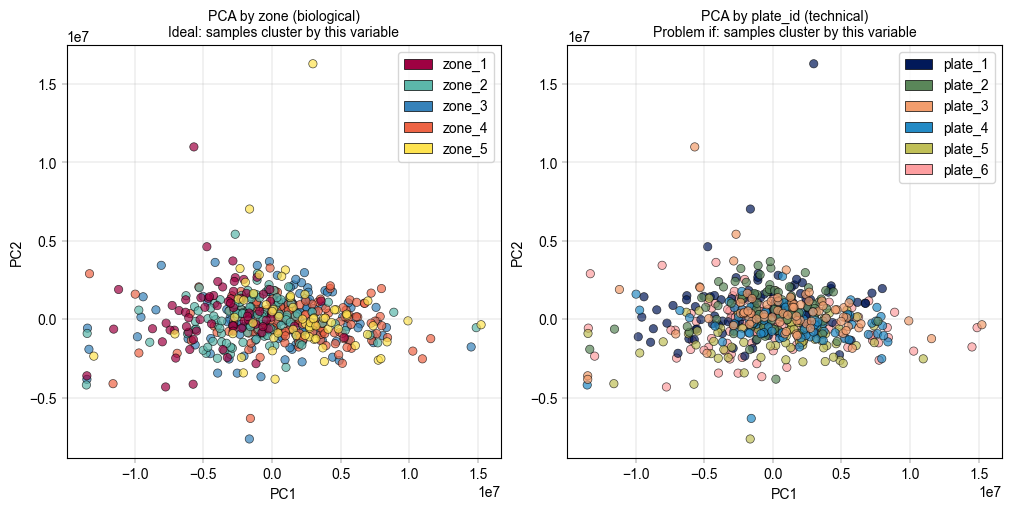

In [ ]:
# PCA colored by biological and technical covariates
fig, axm = create_figure(1, 2, figsize=(10, 5))

# By biological covariate
ax = axm.next()
at.pl.Plots.plot_pca(
    ax=ax,
    data=adata_filtered,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=biological,
    color_dict=biological_color_dict,  # keep coloring consistent with previous plots
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {biological} (biological)\nIdeal: samples cluster by this variable",
)

# By technical covariate
ax = axm.next()
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=ax,
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=technical,
    color_dict=technical_color_dict,
    legend="auto",
    scatter_kwargs={"alpha": 0.7, "linewidth": 0.5, "edgecolor": "black"},
)
label_axes(
    ax=ax,
    xlabel="PC1",
    ylabel="PC2",
    title=f"PCA by {technical} (technical)\nProblem if: samples cluster by this variable",
)

plt.show()

### Observation:

We do see some association between PC1 and zonation, which is as we expected. However, overall separation is weak and samples appear to be bunched together in one distribution.

### Conclusion:

It is important to note that this PCA is performed on only 30 core proteins (minus contaminants). Much of the dataset variability is not captured by this PCA. However, it is still useful to plot and understand the PCA for QC. 

## 13.2 Scree Plot: Understanding the variance structure

The scree plot shows how much variance each principal component explains.

**Interpretation:**
- **Steep drop after PC1**: One dominant source of variation (experience tells that batch effects often show up here. Frequently, the first component is then also dominated by a technical variability term)
- **Gradual decline**: Multiple sources of variation contributing
- **Elbow point**: Rough guide for how many PCs capture meaningful signal

**What to look for:**
- If PC1 explains >30-40% variance, investigate what's driving it
- Compare variance explained with number of conditions in your data

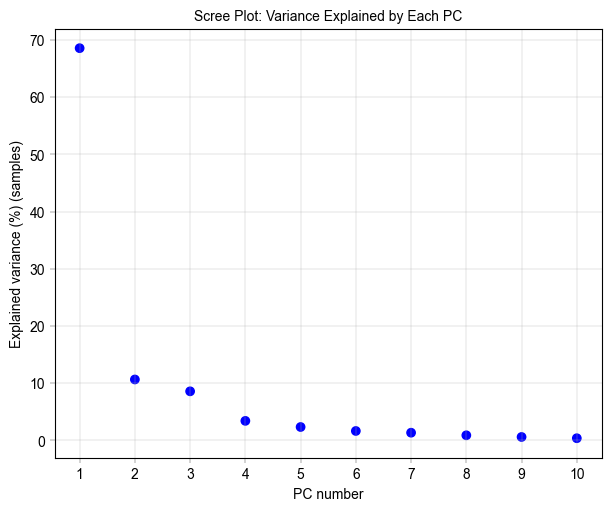

In [ ]:
# Scree plot: variance explained by each PC


fig, axm = create_figure(1, 1, figsize=(6, 5))
ax = axm.next()

at.pl.Plots.scree_plot(adata=adata_filtered, ax=ax, n_pcs=10)

label_axes(
    ax,
    title="Scree Plot: Variance Explained by Each PC",
)

# Increase axis ticks for better readability
ax.set_xticks(range(1, 11))

plt.show()

### Observation:

There is a pronounced "elbow" phenotype, and the first component far outweighs the remaining ones. after 4-5 components the variance explained is already close to zero.

### Conclusion:

The first component is worth investigating since it drives most of the core proteome variance. Also, after the fourth or fifth component there is no real gain in explained variance anymore, indicating that we don't need 10 components. As mentioned, it is important to note that this PCA is performed on only 30 core proteins. 

## 13.3 PCA Loadings: What Drives Each PC?

For components that capture a lot of variance, it can be very insightful to inspect their composition, i.e., which features (proteins) have the most influence on them. The **loadings** represent the contribution of each original feature to a principal component.
Mathematically, they are the coefficients that define the linear combination of original features forming each PC, and their magnitude indicates how strongly each feature influences that component.


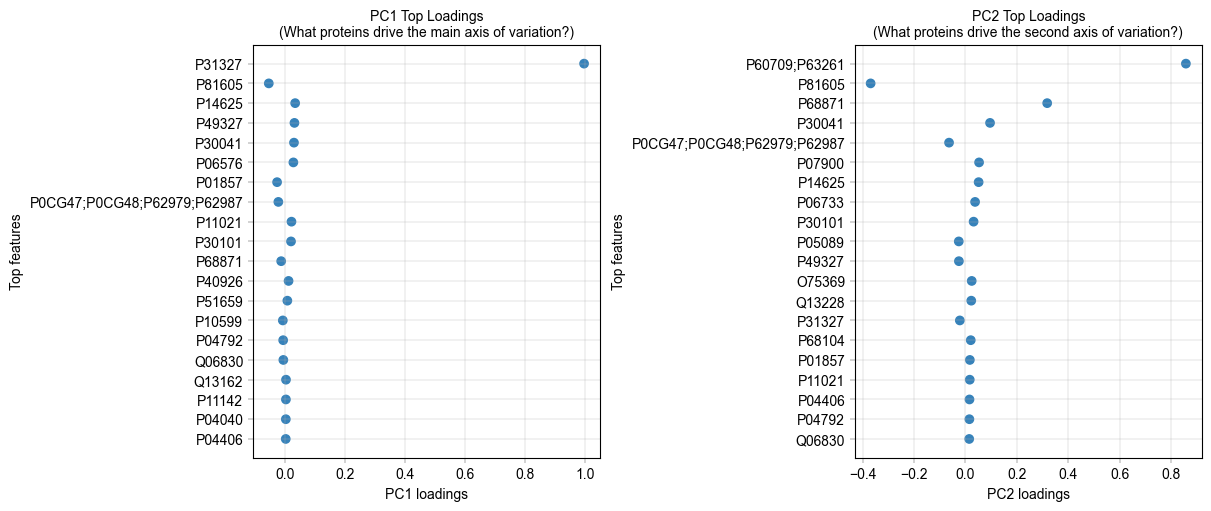

In [ ]:
# Top loadings for PC1
fig, axm = create_figure(1, 2, figsize=(12, 5))

ax = axm.next()
at.pl.Plots.plot_pca_loadings(
    data=adata_filtered,
    ax=ax,
    dim=1,
    nfeatures=20,
)
label_axes(
    ax,
    title="PC1 Top Loadings\n(What proteins drive the main axis of variation?)",
)

ax = axm.next()
at.pl.Plots.plot_pca_loadings(
    data=adata_filtered,
    ax=ax,
    dim=2,
    nfeatures=20,
)
label_axes(
    ax,
    title="PC2 Top Loadings\n(What proteins drive the second axis of variation?)",
)

plt.show()

In [ ]:
# Get the full feature metadata corresponding to the top loadings for PC1
top_pc1_loadings = prepare_pca_1d_loadings_data_to_plot(
    data=adata_filtered,
    dim_space="obs",
    dim=1,
    nfeatures=10,
)
top_pc1_loadings = top_pc1_loadings.merge(
    adata_filtered.var[["Genes"]], left_on="feature", right_index=True, how="left"
)
display(top_pc1_loadings.head(3))

top_pc2_loadings = prepare_pca_1d_loadings_data_to_plot(
    data=adata_filtered,
    dim_space="obs",
    dim=2,
    nfeatures=10,
)
top_pc2_loadings = top_pc2_loadings.merge(
    adata_filtered.var[["Genes"]], left_on="feature", right_index=True, how="left"
)
display(top_pc2_loadings.head(3))

,dim_loadings,feature,abs_loadings,index_int,Genes
0,0.995329,P31327,0.995329,10,CPS1
1,-0.053720,P81605,0.053720,9,DCD
2,0.033991,P14625,0.033991,8,HSP90B1


,dim_loadings,feature,abs_loadings,index_int,Genes
0,0.857972,P60709;P63261,0.857972,10,ACTB;ACTG1
1,-0.368936,P81605,0.368936,9,DCD
2,0.318159,P68871,0.318159,8,HBB


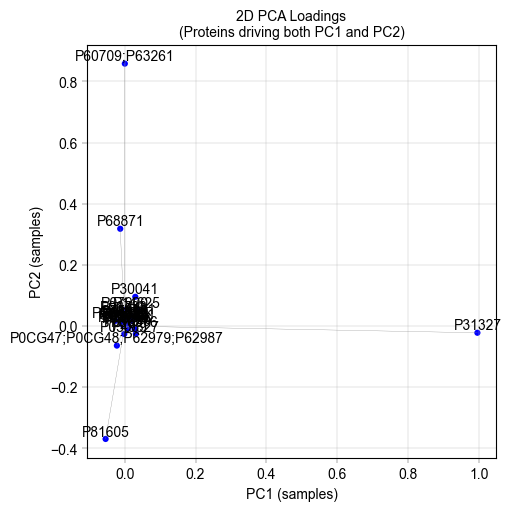

In [ ]:
# 2D loadings plot

fig, axm = create_figure(1, 1, figsize=(5, 5))
ax = axm.next()

at.pl.Plots.plot_pca_loadings_2d(
    data=adata_filtered,
    ax=ax,
    pc_x=1,
    pc_y=2,
    nfeatures=20,
    add_labels=True,
    add_lines=True,
)

label_axes(ax, title="2D PCA Loadings\n(Proteins driving both PC1 and PC2)")

plt.show()

### Observation:

The first component is mainly driven by the protein P31327 (CPS1), the second component is mainly driven by P60709;P63261 (ACTB;ACTG1), P81605 (DCD) and P68871 (HBB). The remaining loadings are uniformly low.

### Conclusion:

These proteins warrant special interest. A quick breakdown suggests that:

- CPS1 (Carbamoyl-phosphate synthase 1) is heavily dependent on liver zonation, so it is a plausible biological driver of variance here (https://www.nature.com/articles/s42255-019-0109-9)
- HBB (Hemoglobin Beta) could indicate contamination
- DCD (Dermicidin) could indicate contamination
- ACTB/ACTG1 (cytoplasmic actins) could indicate variability in cell lysis

This PCA is used primarily for quality control and exploratory validation rather than formal analysis. The interpretation is limited by the small number of proteins included in the analysis, the dominance of PC1 (>70% explained variance) and the disproportionate contribution of a small subset of proteins to the principal component loadings. Despite these limitations, zonation appears to associate with PC1. 
Such PCA analysis can hint that additional preprocessing or filtering steps may be necessary if expected biological signals are not captured in the main PCs.

## 13.4 Overlaying PCA with QC metrics

Coloring PCA by QC metrics can reveal if technical factors are driving the main axes of variation.

INFO:root:Column 'num_proteins' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'log10_sum_intensity' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'P05177' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that
INFO:root:Column 'P00966' found in: data.obs.columns. Using that
INFO:root:Column 'pc_1' found in: data.var_names. Using that
INFO:root:Column 'pc_2' found in: data.var_names. Using that


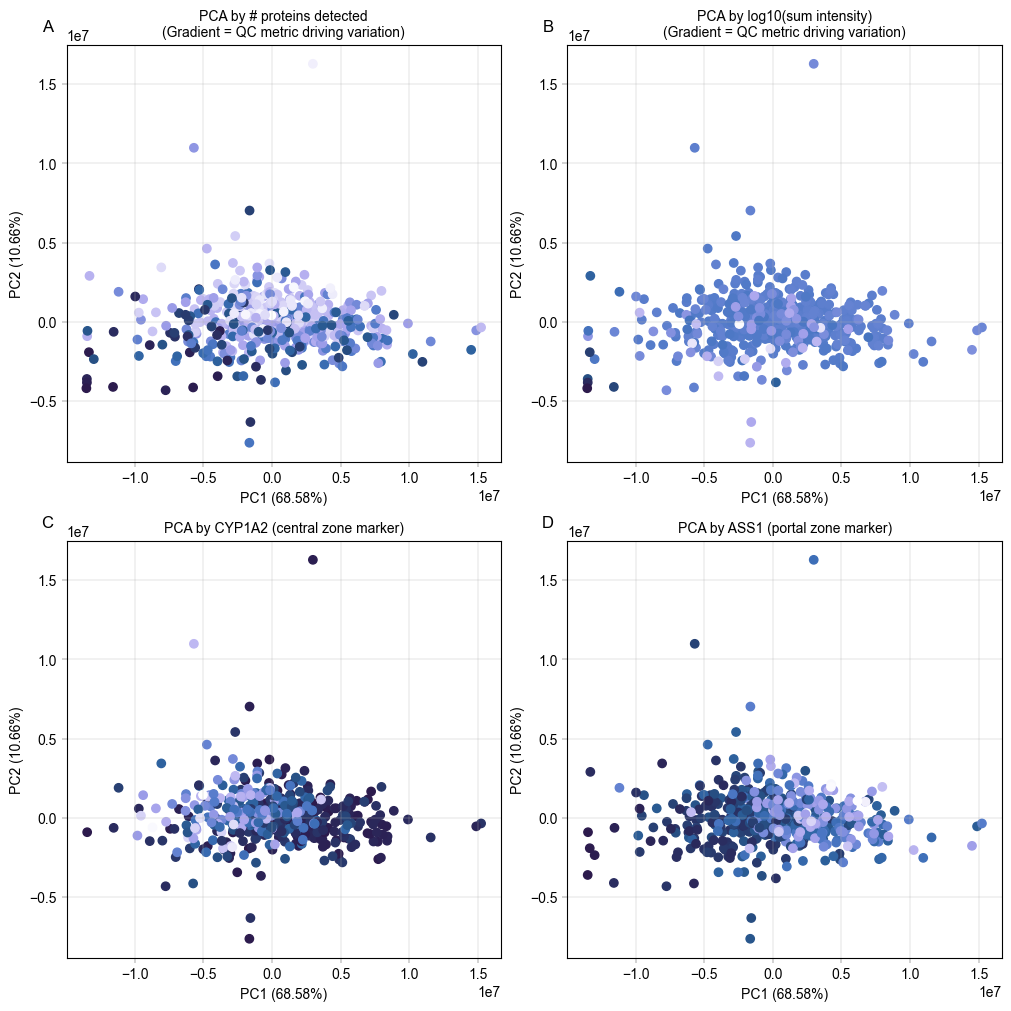

In [ ]:
# PCA colored by QC metrics
fig, axm = create_figure(2, 2, figsize=(10, 10))

# Number of proteins detected
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axm[0, 0],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="num_proteins",
    palette=BaseColormaps.get("sequential"),
)

# axes[0, 0].set_title("PCA by # proteins detected\n(Gradient = QC metric driving variation)")
label_axes(
    axm[0, 0],
    title="PCA by # proteins detected\n(Gradient = QC metric driving variation)",
    enumeration="A",
)

# Sum intensity
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axm[0, 1],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column="log10_sum_intensity",
    palette=BaseColormaps.get("sequential"),
)

label_axes(
    axm[0, 1],
    title="PCA by log10(sum intensity)\n(Gradient = QC metric driving variation)",
    enumeration="B",
)

# Known marker: CYP1A2 (central zone)
prot = "P05177"
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axm[1, 0],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=BaseColormaps.get("sequential"),
)
# axes[1, 0].set_title("PCA by CYP1A2 (central zone marker)")
label_axes(
    axm[1, 0],
    title="PCA by CYP1A2 (central zone marker)",
    enumeration="C",
)

# Known marker: ASS1 (portal zone)
prot = "P00966"
at.pl.Plots.plot_pca(
    data=adata_filtered,
    ax=axm[1, 1],
    x_column=1,
    y_column=2,
    label=False,
    color_map_column=prot,
    palette=BaseColormaps.get("sequential"),
)

label_axes(
    axm[1, 1],
    title="PCA by ASS1 (portal zone marker)",
    enumeration="D",
)

plt.show()

### Observation:

Despite being performed only on the core proteome, we can see that samples appear to separate by the number of proteins which were detected in them (A), as well as by liver zonation markers (C and D). Interestingly, CYP1A2 and ASS1 show an inverse gradient, which is concurrent with their function as central- and portal zone markers, respectively.

### Conclusion:

The PCA plots show that PC1 correlates with zonation and known zonated genes, indicating that even when performed using only a few dozen proteins, PCA still captures the spatial variability of hepatocytes.

---


## 14. Recreating Study Figures: Zonation Heatmap (Figure 2B)

## 14.1 The Zonation Heatmap

This visualization shows protein expression patterns across the portal-central axis, revealing which proteins are enriched in different liver zones.

### Construction Method
1. **Z-score normalization per donor**: Removes donor-specific baseline differences
2. **Bin samples by zonation score**: Group into discrete zones (the study used 20 bins from portal to central, we will use 5)
3. **Average Z-scores per bin**: Creates smooth gradient across zones
4. **Sort proteins by peak position**: Orders proteins by where they're most expressed

### Biological Interpretation

| Pattern | Meaning | Example Proteins |
|---------|---------|-----------------|
| High in bin 1 (central) | Pericentral-enriched | GLUL, CYP2E1, CYP1A2 |
| High in bin 5 (portal) | Periportal-enriched | CPS1, ASS1, PCK1 |
| Flat across bins | Non-zonated (housekeeping) | GAPDH, Actins |


### > Note:

This part of the demo notebook departs somewhat from `alphapepttools`' core functionalities. This highlights one of our guiding design principles, namely to avoid closed "end to end" pipelines and allow full interface with open-source Python tools. As we see below, going from `AnnData` to `DataFrame` and applying custom Python code is a seamless transition.

In [ ]:
from scipy.stats import zscore

# Convert adata.X to DataFrame (cells x proteins)
expr_df = pd.DataFrame(
    adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X, index=adata.obs_names, columns=adata.var_names
)

# List to collect per-donor binned means
binned_means_list = []

# Iterate over donors
for _donor, donor_cells in adata.obs.groupby("donor_id"):
    # Select expression for this donor
    donor_expr = expr_df.loc[donor_cells.index]
    # Calculate z-score per protein, ignoring NaNs
    donor_z = donor_expr.apply(lambda x: zscore(x, nan_policy="omit"), axis=0, result_type="broadcast")
    # Bin cells into 5 bins based on 'score'
    bins = pd.qcut(donor_cells["score"], q=5, labels=False) + 1  # bins 1-5
    donor_z["bin"] = bins
    # Calculate mean z-score per protein per bin, ignoring NaNs
    mean_per_bin = donor_z.groupby("bin").mean().T  # proteins as rows
    binned_means_list.append(mean_per_bin)

# Combine all donors: take mean across donors, ignoring NaNs
zone_z_means = pd.concat(binned_means_list, axis=0).groupby(level=0).mean()

  for _donor, donor_cells in adata.obs.groupby("donor_id"):



### Plotting the zonation heatmap:

  max_bin = zone_z_means.idxmax(axis=1)  # returns the column (bin) of max value per protein



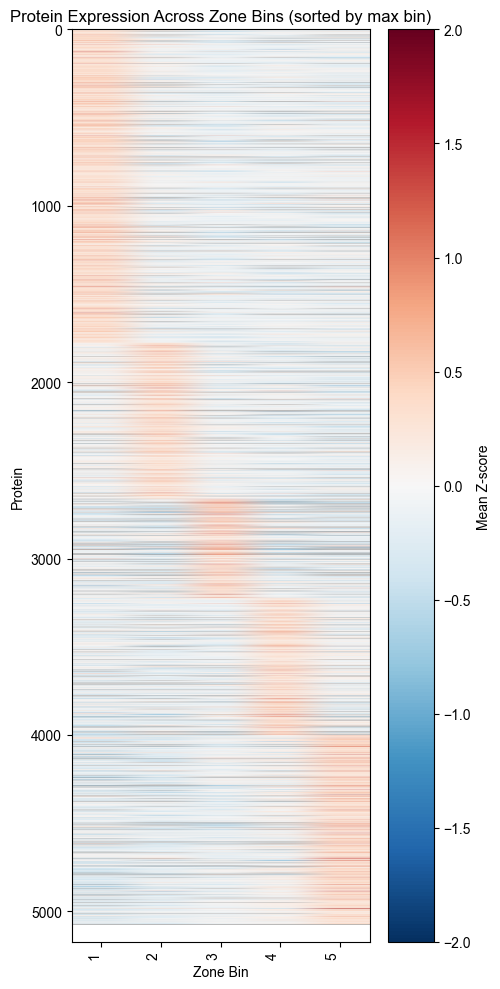

In [ ]:
max_bin = zone_z_means.idxmax(axis=1)  # returns the column (bin) of max value per protein

# Sort proteins first by the bin of max value, then by max value descending
zone_z_means["max_bin"] = max_bin

# Sort by max_bin (ascending) and then max_value (descending)
zone_z_means_sorted = zone_z_means.sort_values(["max_bin"], ascending=True)

# Drop helper columns before plotting
zone_z_means_sorted = zone_z_means_sorted.drop(columns=["max_bin"])

# Plot heatmap
fig, ax = plt.subplots(figsize=(5, 10))
im = ax.imshow(zone_z_means_sorted.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)

ax.set_xlabel("Zone Bin")
ax.set_ylabel("Protein")
ax.set_xticks(range(len(zone_z_means_sorted.columns)))
ax.set_xticklabels(zone_z_means_sorted.columns, rotation=90, ha="right")

plt.colorbar(im, ax=ax, label="Mean Z-score")
plt.title("Protein Expression Across Zone Bins (sorted by max bin)")
plt.tight_layout()
plt.show()

---


## 14.2 Transcription Factor Activity Inference with Decoupler

### Why Infer TF Activity?

Proteomics measures **protein abundance**, but biological function is often controlled by **transcription factor (TF) activity**. 

**Key insight**: If a TF's target proteins are consistently upregulated, we can infer that TF is more active - even if we don't directly measure the TF itself.

### Decoupler Framework

We use **decoupler** to estimate TF activity from protein abundance:

1. **Prior Knowledge**: TF-target relationships from CollecTRI database
2. **Activity Score**: Statistical measure of target enrichment (ULM method)
3. **Comparison**: Identify TFs with differential activity across zones

### Important Caveats

- **Protein vs mRNA**: TF-target databases are often defined at mRNA level
- **Coverage**: Limited overlap between detected proteins and known TF targets
- **Post-translational regulation**: TF activity ≠ TF abundance (phosphorylation, localization matter)

Despite these limitations, TF activity inference provides biological insight beyond individual protein changes and can reveal regulatory mechanisms driving zonation patterns.

Import decoupler package:

In [ ]:
# decoupler imports
import decoupler as dc

  from .autonotebook import tqdm as notebook_tqdm



### 14.2.1 Data preparation

- log transform (while making sure we're working on the right layer), where we choose the `log1p` function from `scanpy`, as ULM doesn't accept nan values.

In [ ]:
adata_dc = adata_filtered.copy()

adata_dc.X = adata_dc.layers["zero_filled"].copy()
sc.pp.log1p(adata_dc, base=2)

- Loading the TF-target dataset from the package and check intersection:

In [ ]:
# Get CollecTRI TF-target network
collectri = dc.op.collectri(organism="human")

print(f"CollecTRI network: {len(collectri)} TF-target interactions")
print(f"Number of TFs: {collectri['source'].nunique()}")
print(f"Number of target genes: {collectri['target'].nunique()}")
print("\nNetwork structure:")
display(collectri.head(10))

# Check overlap between our proteins and the TF-target network
our_genes = set(adata_dc.var["single_gene_name"])
network_targets = set(collectri["target"])
overlap = our_genes.intersection(network_targets)

print(f"Genes in our data: {len(our_genes)}")
print(f"Target genes in network: {len(network_targets)}")
print(f"Overlap: {len(overlap)} ({100 * len(overlap) / len(our_genes):.1f}%)")

print(f"number of overlapping proteins is {len(overlap)}, make sure it is sufficient for robust TF activity inference.")


# make unique row indices
adata_dc.var_names = adata_dc.var["single_gene_name"]
print(adata_dc.var_names)

adata_dc.var_names_make_unique()
adata_dc.shape

CollecTRI network: 42990 TF-target interactions
Number of TFs: 1185
Number of target genes: 6675

Network structure:


,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
5,STAT5B,IL2,1.0,ExTRI,10022878,regulon
6,RELA,FAS,1.0,ExTRI;NTNU.Curated;TRRUST,10022897;10871852;11290773;11473033;16317104;1...,PMID
7,WT1,NR0B1,1.0,ExTRI;GEREDB,10022915;12151099,PMID
8,NR0B2,CASP1,1.0,ExTRI,10022928,default activation
9,SP1,ALDOA,1.0,DoRothEA-A;ExTRI;TFactS,10023068;8524331,PMID


Genes in our data: 1656
Target genes in network: 6675
Overlap: 840 (50.7%)
number of overlapping proteins is 840, make sure it is sufficient for robust TF activity inference.
Index([   'GATD3',  'TRBJ1-3',     'UBA6',    'SHTN1',    'ILVBL', 'ANKRD18B',
           'FUOM',     'VWA8',  'USP17L1',    'ASPDH',
       ...
          'PSAT1', 'SLC25A15',     'ALG5',    'COPG1',    'CLIC4',    'SPCS1',
        'EMILIN1',    'MTCH2',  'SLCO1B1',     'SQOR'],
      dtype='object', name='single_gene_name', length=1656)


(531, 1656)

---


### 14.2.2 Running TF Activity Inference

Decoupler provides multiple methods for activity inference. We'll use `run_ulm` (Univariate Linear Model) as the primary method, which performs a linear regression for each TF.

In [ ]:
# Run Univariate Linear Model (ULM) for TF activity inference
dc.mt.ulm(
    data=adata_dc,
    net=collectri,
    verbose=True,
    raw=False,
)

# Results are stored in adata.obsm
print("\nResults stored in:")
print("  - adata_dc.obsm['ulm_estimate']: TF activity scores")
print("  - adata_dc.obsm['ulm_pvals']: p-values")

INFO:root:ulm - Running ulm
INFO:root:Extracted omics mat with 531 rows (observations) and 1656 columns (features)
INFO:root:Network adjacency matrix has 802 unique features and 214 unique sources
INFO:root:ulm - fitting 214 univariate models of 1656 observations (targets) with 1654 degrees of freedom
INFO:root:ulm - adjusting p-values by FDR
INFO:root:ulm - done



Results stored in:
  - adata_dc.obsm['ulm_estimate']: TF activity scores
  - adata_dc.obsm['ulm_pvals']: p-values


### 14.2.3 Extracting TF activity 

Whereby we estimate and show the top 20 active TFs in the hepatocytes and the top 20 variable TFs:

In [ ]:
tf_activities = adata_dc.obsm["score_ulm"]
tf_pvals = adata_dc.obsm["padj_ulm"]

# calculate tf_activities column means
tf_activities_means = tf_activities.mean()
# sort by means
tf_activities_means = tf_activities_means.sort_values(ascending=False)
print("\nTop TFs by mean activity:")
print(tf_activities_means.head(20))

# variance of tf_activities
tf_var = tf_activities.var().sort_values(ascending=False)
print("\nTop TFs by activity variance:")
print(tf_var.head(20))


Top TFs by mean activity:
CEBPB     4.953113
CEBPG     3.854207
CEBPA     3.590686
PPARA     3.583710
SP1       3.357533
DBP       3.033312
KLF11     2.968757
RARB      2.808760
MYC       2.707510
PPARG     2.705729
JUN       2.525194
GATA4     2.515054
HIF1A     2.514218
HNF4A     2.511992
DDIT3     2.495306
SREBF1    2.482112
NFE2L2    2.439815
ESR1      2.428437
NFYB      2.381509
NR3C1     2.356416
dtype: float64

Top TFs by activity variance:
SRSF2     2.107434
SMAD3     2.013538
NCOA3     1.918451
CEBPE     1.880043
MBD2      1.667031
HNF1A     1.482369
NR1I3     1.326112
CREM      1.313287
MAF       1.214274
REL       1.199312
CEBPB     1.196911
PAX6      1.157677
VDR       1.149391
SMAD7     1.141421
NFAT5     1.139039
SP1       1.131627
EP300     1.080585
NKX2-5    1.075080
HNF4G     1.068666
CUX1      1.067786
dtype: float64


### 14.2.4 Compare TF Activities Between Cetral and Portal zones


In [ ]:
# Add condition to activities dataframe
tf_activities_df = tf_activities.copy()
tf_activities_df["zone"] = adata_dc.obs["zone"].to_numpy()

# Calculate mean activity per condition
mean_by_condition = tf_activities_df.groupby("zone").mean()

# Calculate activity difference (AD - Control)
activity_diff = mean_by_condition.loc["zone_1"] - mean_by_condition.loc["zone_5"]
activity_diff = activity_diff.sort_values()

print("TFs more active in zone 1 - central (top 10):")
print(activity_diff.tail(10))
print("\nTFs less active in zone 5 - portal (top 10):")
print(activity_diff.head(10))

TFs more active in zone 1 - central (top 10):
DBP      0.886203
HR       0.886828
USF1     0.903145
NR1H3    0.941595
NR1I2    0.942652
VDR      0.973535
ARNT     1.182978
AHR      1.218691
HNF1A    1.423092
NR1I3    1.426813
dtype: float64

TFs less active in zone 5 - portal (top 10):
MAF     -1.107194
RELA    -0.943795
NCOR2   -0.935433
FOXO1   -0.749511
ETS2    -0.615703
SMAD7   -0.454564
MEF2C   -0.414948
NR4A1   -0.414334
ATF6    -0.359321
CIITA   -0.353438
dtype: float64


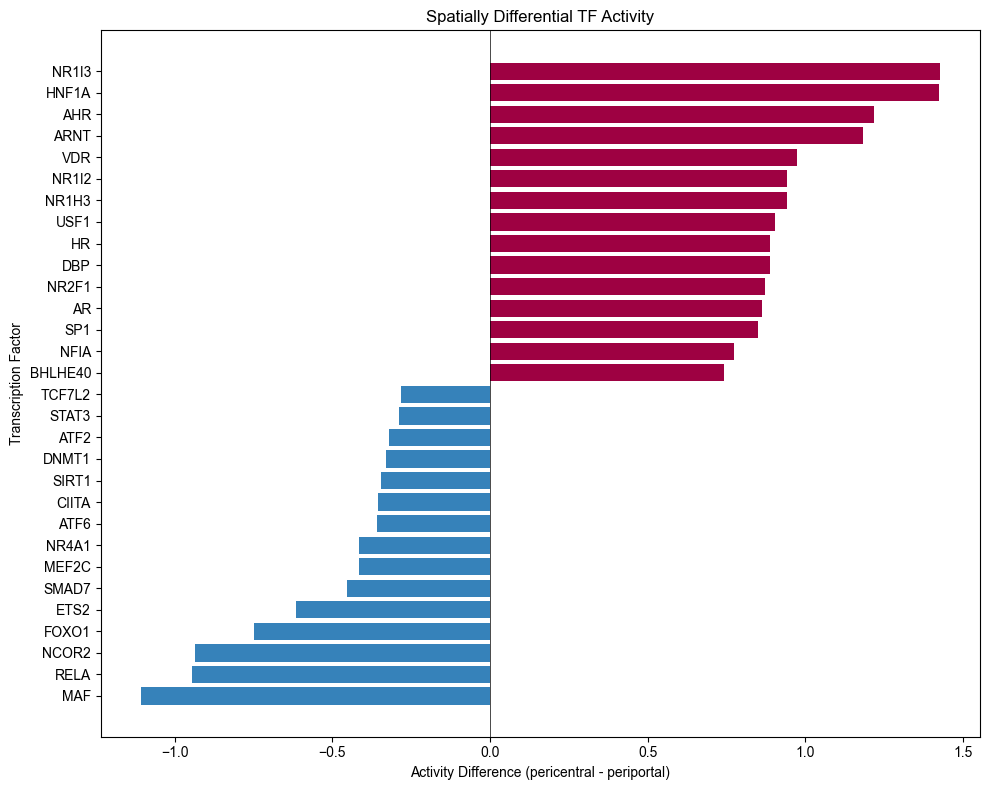

In [ ]:
# Plot top differential TFs
n_top = 15
top_up = activity_diff.tail(n_top)
top_down = activity_diff.head(n_top)
top_diff = pd.concat([top_down, top_up])

fig, ax = plt.subplots(figsize=(10, 8))
colors = [BaseColors.get("blue") if x < 0 else BaseColors.get("red") for x in top_diff.to_numpy()]
ax.barh(range(len(top_diff)), top_diff.to_numpy(), color=colors)
ax.set_yticks(range(len(top_diff)))
ax.set_yticklabels(top_diff.index)
ax.axvline(x=0, color="black", linewidth=0.5)
ax.set_xlabel("Activity Difference (pericentral - periportal)")
ax.set_ylabel("Transcription Factor")
ax.set_title("Spatially Differential TF Activity")

plt.tight_layout()
plt.show()

### Observation
The identified highest differential TF NR1I3 was indeed found to induce pericentral functions in the liver (https://www.sciencedirect.com/science/article/pii/S1534580725006653?via%3Dihub). Inversely, the lowest differential TF MAF was found to be associated with silencing the pericentral functions, where MAF deletion resulted in larger pericentral areas (hepatocytes remoted from CV also exressed GS, otherwise exclussively expressed by pericentral hepatocytes: https://www.sciencedirect.com/science/article/pii/S1934590922001096). 

### Conclusion
This anecdotal validation using literature concordance serves as a technical validation rather than biological inference, confirming that our approach recovers expected zonation-associated TFs.


## 14.3 Violin Plots for Specific TFs

Examining the distribution of activity scores for specific TFs of interest.

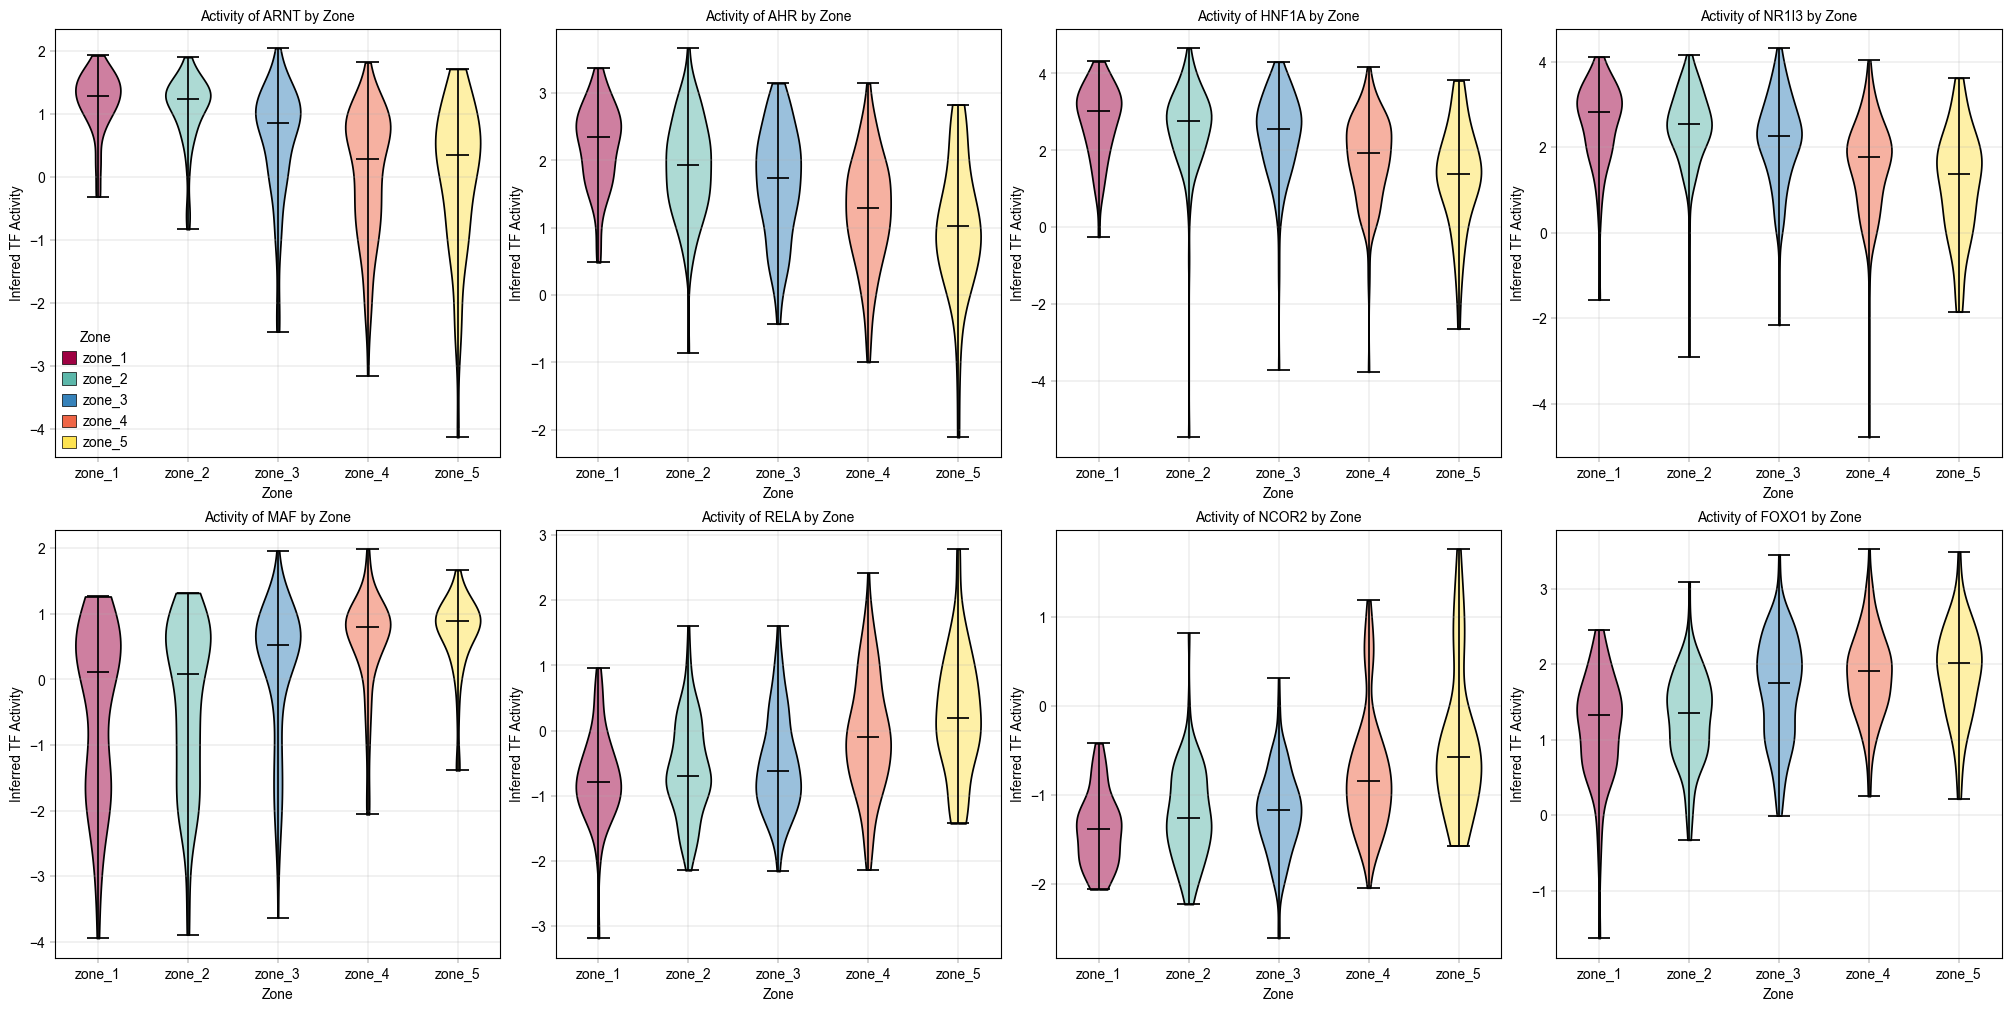

In [ ]:
# Select TFs to visualize
tfs_to_plot = top_diff.tail(4).index.tolist() + top_diff.head(4).index.tolist()
tfs_to_plot = [tf for tf in tfs_to_plot if tf in tf_activities.columns]

if len(tfs_to_plot) > 0:
    # Create AnnData with TF activities for easy plotting with scanpy
    adata_tf = ad.AnnData(
        X=tf_activities.values, obs=adata_dc.obs.copy(), var=pd.DataFrame(index=tf_activities.columns)
    )

    # Plot violin plots
    fig, axm = create_figure(2, 4, figsize=(20, 10))

    for i, tf in enumerate(tfs_to_plot[:8]):
        if tf in adata_tf.var_names:
            ax = axm[i]

            at.pl.Plots.violinplot(
                ax=ax,
                data=adata_tf,
                grouping_column="zone",
                value_column=tf,
                color_dict=biological_color_dict,
            )

            label_axes(
                ax,
                title=f"Activity of {tf} by Zone",
                xlabel="Zone",
                ylabel="Inferred TF Activity",
            )

            # Add a legend to the first plot for clarity
            if i == 0:
                at.pl.add_legend_to_axes(
                    ax,
                    levels=biological_color_dict,
                    title="Zone",
                )

    plt.show()

---


## 15. Summary & Key Takeaways

### What We Accomplished

1. **Data Loading**: Imported scDVP proteomics data into AnnData format with alphapepttools
2. **Quality Control**: Assessed sample and protein quality, identified technical vs biological variation
3. **Filtering**: Applied manuscript-based thresholds for samples and proteins
4. **PCA Analysis**: Explored variance structure, confirmed biological signal
5. **Zonation Heatmap**: Recreated Figure 2B showing protein gradients across liver zones
6. **TF Activity**: Inferred transcription factor activity differences between zones

### Key Proteomics Insights

### Things to Watch Out For
- **Missing values are NOT random**: Low-abundance proteins have more missingness
- **Contaminants dominate**: Consider excluding from some analyses
- **Batch effects**: Always check if technical factors drive variance

### Next Steps
- Apply batch correction if needed (ComBat)
- If needed, consider imputation and/or additional normalization, and assess the QC metrics again to see if there is an improvement


